## Análise de dados e aplicação de algoritmos de *machine learning*.

### Nessa primeira seção, apresentam-se alguns dados de interesse a partir do dataset com os dados individuais, prévios ao agrupamento pelos municípios.

In [88]:
import pandas as pd

# Carregar os dados
df_enem_sp = pd.read_csv('data/df_enem_sp.csv')
print("Dados carregados com sucesso!")

Dados carregados com sucesso!


#### Top 10 maiores médias das provas objetivas

In [89]:
# Ordenar pela coluna 'media_notas_objetivas', de maneira decrescente
top_media_notas = df_enem_sp.sort_values(by='media_notas_objetivas', ascending=False)

# Exibir as dez primeiras linhas do DataFrame
display(top_media_notas.head(10))
print("""\nObserva-se que, dos 10 alunos com as maiores médias das provas objetivas,
todos eles são oriundos de escolas privadas, sendo 9 de escolas particulares
e 1 de uma escola filantrópica, o que mostra proeminência de escolas privadas.""")

,municipio,nota_ciencias_natureza,nota_ciencias_humanas,nota_linguagens_codigos,nota_matematica,nota_redacao,media_notas_objetivas,cat_adm,dep_adm,cat_esc_priv
98064,São José dos Campos,867.2,795.0,680.6,961.9,960.0,826.2,Privada,Privada,Particular
138703,São Paulo,778.1,792.8,774.7,904.9,900.0,812.6,Privada,Privada,Particular
97407,Ribeirão Preto,824.6,769.3,693.5,961.9,920.0,812.3,Privada,Privada,Particular
164179,São José dos Campos,836.8,741.0,726.4,935.0,940.0,809.8,Privada,Privada,Particular
210075,Mogi das Cruzes,819.3,765.2,665.0,961.9,860.0,802.8,Privada,Privada,Particular
135092,Jundiaí,787.0,808.2,652.4,961.9,780.0,802.4,Privada,Privada,Particular
172414,Ribeirão Preto,797.3,770.3,695.0,941.7,900.0,801.1,Privada,Privada,Particular
196426,São Paulo,761.1,776.3,703.9,961.9,920.0,800.8,Privada,Privada,Particular
190698,São Paulo,789.0,794.0,681.2,927.4,880.0,797.9,Privada,Privada,Particular
20126,São Paulo,803.0,808.2,614.3,961.9,940.0,796.8,Privada,Privada,Filantrópica



Observa-se que, dos 10 alunos com as maiores médias das provas objetivas,
todos eles são oriundos de escolas privadas, sendo 9 de escolas particulares
e 1 de uma escola filantrópica, o que mostra proeminência de escolas privadas.


#### Top notas da prova de redação (pontuação >= 900.0).

In [90]:
# Ordenar pela coluna 'nota_redacao', de maneira decrescente; em caso de empate, o desempate será dado pela coluna 'media_notas_objetivas'
top_notas_redacao = df_enem_sp.sort_values(by=['nota_redacao','media_notas_objetivas'], ascending=False)

display(top_notas_redacao.head(10))

# Criar variável que conte a quantidade de ocorrências em que nota_redacao == 1000.0
count_1000 = (df_enem_sp['nota_redacao'] == 1000.0).sum()

# Criar variável que conte a quantidade de ocorrências em que nota_redacao >= 900.0
count_900_or_more = ((df_enem_sp['nota_redacao'] >= 900.0) & (df_enem_sp['nota_redacao'] < 1000.0)).sum()

# Criar variável que conte a quantidade de ocorrências em que nota_redacao >= 900.0 e cat_adm == 'Privada'
count_900_or_more_privada = ((df_enem_sp['nota_redacao'] >= 900.0) & (df_enem_sp['nota_redacao'] < 1000.0) & (df_enem_sp['cat_adm'] == 'Privada')).sum()

# Criar variável que conte a quantidade de ocorrências em que nota_redacao >= 900.0 e cat_esc_priv == 'Particular'
count_900_or_more_particular = ((df_enem_sp['nota_redacao'] >= 900.0) & (df_enem_sp['nota_redacao'] < 1000.0) & (df_enem_sp['cat_esc_priv'] == 'Particular')).sum()

# Criar variável que conte a quantidade de ocorrências em que nota_redacao >= 900.0 e cat_esc_priv == 'Filantrópica'
count_900_or_more_filantropica = ((df_enem_sp['nota_redacao'] >= 900.0) & (df_enem_sp['nota_redacao'] < 1000.0) & (df_enem_sp['cat_esc_priv'] == 'Filantrópica')).sum()

# Criar variável que conte a quantidade de ocorrências em que nota_redacao >= 900.0 e cat_esc_priv == 'Comunitária'
count_900_or_more_comunitaria = ((df_enem_sp['nota_redacao'] >= 900.0) & (df_enem_sp['nota_redacao'] < 1000.0) & (df_enem_sp['cat_esc_priv'] == 'Comunitária')).sum()

# Criar variável que conte a quantidade de ocorrências em que nota_redacao >= 900.0 e cat_esc_priv == 'Confessional'
count_900_or_more_confessional = ((df_enem_sp['nota_redacao'] >= 900.0) & (df_enem_sp['nota_redacao'] < 1000.0) & (df_enem_sp['cat_esc_priv'] == 'Confessional')).sum()

# Criar variável que conte a quantidade de ocorrências em que nota_redacao >= 900.0 e cat_adm == 'Pública'
count_900_or_more_publica = ((df_enem_sp['nota_redacao'] >= 900.0) & (df_enem_sp['nota_redacao'] < 1000.0) & (df_enem_sp['cat_adm'] == 'Pública')).sum()

# Criar variável que conte a quantidade de ocorrências em que nota_redacao >= 900.0 e dep_adm == 'Estadual'
count_900_or_more_estadual = ((df_enem_sp['nota_redacao'] >= 900.0) & (df_enem_sp['nota_redacao'] < 1000.0) & (df_enem_sp['dep_adm'] == 'Estadual')).sum()

# Criar variável que conte a quantidade de ocorrências em que nota_redacao >= 900.0 e dep_adm == 'Federal'
count_900_or_more_federal = ((df_enem_sp['nota_redacao'] >= 900.0) & (df_enem_sp['nota_redacao'] < 1000.0) & (df_enem_sp['dep_adm'] == 'Federal')).sum()

# Criar variável que conte a quantidade de ocorrências em que nota_redacao >= 900.0 e dep_adm == 'Municipal'
count_900_or_more_municipal = ((df_enem_sp['nota_redacao'] >= 900.0) & (df_enem_sp['nota_redacao'] < 1000.0) & (df_enem_sp['dep_adm'] == 'Municipal')).sum()

print(f"""
Analisando as maiores notas de redação, temos que:
- Há {count_1000} aluno com nota máxima em redação.
- Há {count_900_or_more} alunos com notas maiores ou iguais a 900.0.
- Desses alunos:
  - {count_900_or_more_privada} são oriundos de escolas privadas, dos quais:
    - {count_900_or_more_particular} são de escolas particulares.
    - {count_900_or_more_filantropica} são de escolas filantrópicas.
    - {count_900_or_more_confessional} são de escolas confessionais.
    - {count_900_or_more_comunitaria} são de escolas comunitárias.
  - {count_900_or_more_publica} são oriundos de escolas públicas, dos quais:
    - {count_900_or_more_estadual} são de escolas estaduais.
    - {count_900_or_more_federal} são de escolas federais.
    - {count_900_or_more_municipal} são de escolas municipais.
------------------------------------------
Observa-se proeminência dos resultados obtidos por escolas privadas
- com destaque para escolas particulares.
""")

,municipio,nota_ciencias_natureza,nota_ciencias_humanas,nota_linguagens_codigos,nota_matematica,nota_redacao,media_notas_objetivas,cat_adm,dep_adm,cat_esc_priv
185511,Araçatuba,735.4,671.4,675.3,876.2,1000.0,739.6,Privada,Privada,Particular
205011,São João da Boa Vista,741.1,750.7,665.0,925.6,980.0,770.6,Privada,Privada,Particular
185100,São Paulo,719.5,740.9,643.1,931.8,980.0,758.8,Privada,Privada,Particular
139011,Jacareí,691.6,763.3,684.4,883.4,980.0,755.7,Privada,Privada,Particular
109261,Ribeirão Preto,729.4,758.1,686.3,826.6,980.0,750.1,Privada,Privada,Particular
87522,Campinas,733.6,743.4,705.5,809.7,980.0,748.0,Privada,Privada,Filantrópica
180940,São Paulo,707.9,808.2,657.3,817.3,980.0,747.7,Privada,Privada,Filantrópica
49260,São Paulo,697.0,701.2,662.3,913.2,980.0,743.4,Privada,Privada,Filantrópica
119172,Barueri,700.2,710.8,673.5,870.9,980.0,738.8,Privada,Privada,Particular
103514,São Caetano do Sul,682.8,741.5,672.0,833.2,980.0,732.4,Privada,Privada,Particular



Analisando as maiores notas de redação, temos que:
- Há 1 aluno com nota máxima em redação.
- Há 16046 alunos com notas maiores ou iguais a 900.0.
- Desses alunos:
  - 10889 são oriundos de escolas privadas, dos quais:
    - 9196 são de escolas particulares.
    - 1520 são de escolas filantrópicas.
    - 108 são de escolas confessionais.
    - 65 são de escolas comunitárias.
  - 5157 são oriundos de escolas públicas, dos quais:
    - 4541 são de escolas estaduais.
    - 410 são de escolas federais.
    - 206 são de escolas municipais.
------------------------------------------
Observa-se proeminência dos resultados obtidos por escolas privadas
- com destaque para escolas particulares.



In [91]:
# Porcentagem de alunos com nota de redação >= 900.0 por Categoria Administrativa
# Calcular o total de alunos por categoria administrativa
total_alunos_cat_adm = df_enem_sp.groupby('cat_adm').size().reset_index(name='total_alunos')

# Calcular alunos com nota_redacao >= 900.0 por categoria administrativa
alunos_900_cat_adm = df_enem_sp[df_enem_sp['nota_redacao'] >= 900.0].groupby('cat_adm').size().reset_index(name='alunos_redacao_900')

# Juntar os DataFrames
merged_cat_adm = pd.merge(total_alunos_cat_adm, alunos_900_cat_adm, on='cat_adm', how='left').fillna(0)

# Calcular a porcentagem
merged_cat_adm['porcentagem_900'] = ((merged_cat_adm['alunos_redacao_900'] / merged_cat_adm['total_alunos']) * 100).round(2)

display(merged_cat_adm)
print("""\nEm escolas privadas, diante do total de alunos,
aqueles que obtiveram notas maiores do que 900.0 representam 15,9%.
Já em escolas públicas, apenas 3,54%.""")

,cat_adm,total_alunos,alunos_redacao_900,porcentagem_900
0,Privada,68495,10890,15.90
1,Pública,145686,5157,3.54



Em escolas privadas, diante do total de alunos,
aqueles que obtiveram notas maiores do que 900.0 representam 15,9%.
Já em escolas públicas, apenas 3,54%.


In [92]:
# Porcentagem de alunos com nota de redação >= 900.0 por Categoria de Escola Privada
# Filtrar apenas escolas privadas
df_privadas = df_enem_sp[df_enem_sp['cat_adm'] == 'Privada']

# Calcular o total de alunos por categoria de escola privada
total_alunos_cat_esc_priv = df_privadas.groupby('cat_esc_priv').size().reset_index(name='total_alunos')

# Calcular alunos com nota_redacao >= 900.0 por categoria de escola privada
alunos_900_cat_esc_priv = df_privadas[df_privadas['nota_redacao'] >= 900.0].groupby('cat_esc_priv').size().reset_index(name='alunos_redacao_900')

# Juntar os DataFrames
merged_cat_esc_priv = pd.merge(total_alunos_cat_esc_priv, alunos_900_cat_esc_priv, on='cat_esc_priv', how='left').fillna(0)

# Calcular a porcentagem
merged_cat_esc_priv['porcentagem_900'] = ((merged_cat_esc_priv['alunos_redacao_900'] / merged_cat_esc_priv['total_alunos']) * 100).round(2)

display(merged_cat_esc_priv)
print("""\nA partir dos dados acima, as escolas particulares
e filantrópicas têm porcentagens semelhantes, acima das escolas confessonais.
Além desses, os números das escolas comunitárias impressionam:
é como se a cada 5 alunos, 1 obtivesse nota maior do que 900.0 na prova de redação.""")

,cat_esc_priv,total_alunos,alunos_redacao_900,porcentagem_900
0,Comunitária,312,65,20.83
1,Confessional,917,108,11.78
2,Filantrópica,9516,1520,15.97
3,Particular,57750,9197,15.93



A partir dos dados acima, as escolas particulares
e filantrópicas têm porcentagens semelhantes, acima das escolas confessonais.
Além desses, os números das escolas comunitárias impressionam:
é como se a cada 5 alunos, 1 obtivesse nota maior do que 900.0 na prova de redação.


####Média das notas por Categoria Administrativa

,media_notas_objetivas,nota_redacao
cat_adm,,
Privada,578.60,746.92
Pública,508.37,607.60


<Figure size 1200x700 with 0 Axes>

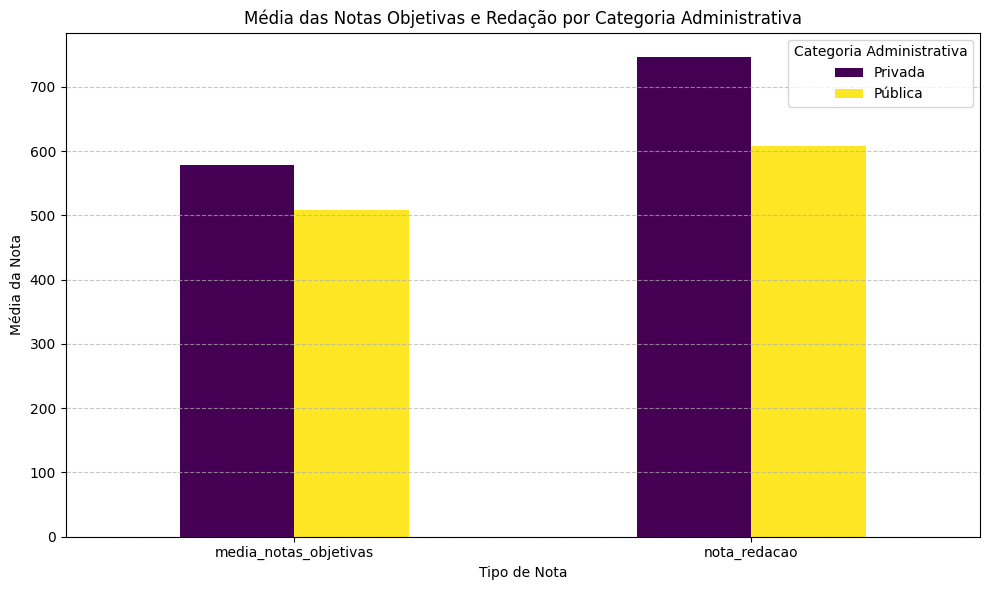


Quando comparadas as médias das provas objetivas entre categorias administrativas,
observa-se números bastante destoantes: pouco mais de 70 pontos. Quando comparadas as notas
das provas de redação, a discrepância é ainda maior.



cat_adm
Privada     68495
Pública    145686
Name: cat_adm, dtype: int64

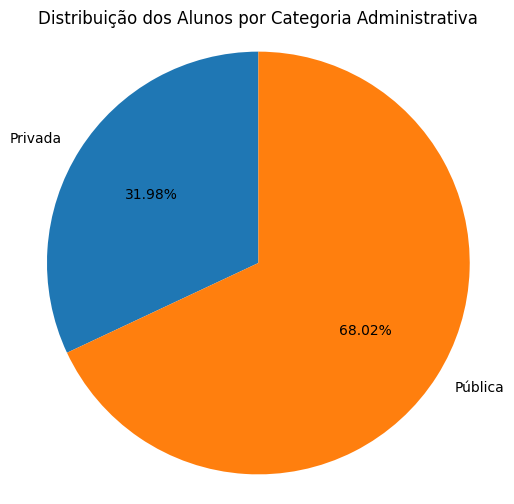


Um dado interessante é o número absoluto de alunos por categoria
administrativa, que talvez ajude a compreender a disparidade entre as notas.
A proporção entre escolas privadas e públicas é de pouco mais do que o dobro.




In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

# Média das notas por Categoria Administrativa
mean_scores_cat_adm = df_enem_sp.groupby('cat_adm')[['media_notas_objetivas', 'nota_redacao']].mean().round(2)
display(mean_scores_cat_adm)

# Transpor o DataFrame para facilitar a plotagem
mean_scores_cat_adm_transposed = mean_scores_cat_adm.transpose()

# Criar o gráfico de barras
plt.figure(figsize=(12, 7))
mean_scores_cat_adm_transposed.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Média das Notas Objetivas e Redação por Categoria Administrativa')
plt.xlabel('Tipo de Nota')
plt.ylabel('Média da Nota')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Categoria Administrativa')
plt.tight_layout()
plt.show()

print("""\nQuando comparadas as médias das provas objetivas entre categorias administrativas,
observa-se números bastante destoantes: pouco mais de 70 pontos. Quando comparadas as notas
das provas de redação, a discrepância é ainda maior.\n""")

# Contagem de escolas por categoria
cat_adm_counts = df_enem_sp.groupby('cat_adm')['cat_adm'].count()
display(cat_adm_counts)

# Plotagem em gráfico de pizza
plt.figure(figsize=(6, 6))
plt.pie(cat_adm_counts, labels=cat_adm_counts.index, autopct='%1.2f%%', startangle=90)
plt.title('Distribuição dos Alunos por Categoria Administrativa')
plt.axis('equal')
plt.show()

print("""\nUm dado interessante é o número absoluto de alunos por categoria
administrativa, que talvez ajude a compreender a disparidade entre as notas.
A proporção entre escolas privadas e públicas é de pouco mais do que o dobro.\n
""")

#### Média das notas por Dependência Administrativa

,media_notas_objetivas,nota_redacao
dep_adm,,
Estadual,506.13,603.74
Federal,581.26,732.13
Municipal,525.94,638.97
Privada,578.60,746.92


<Figure size 1200x700 with 0 Axes>

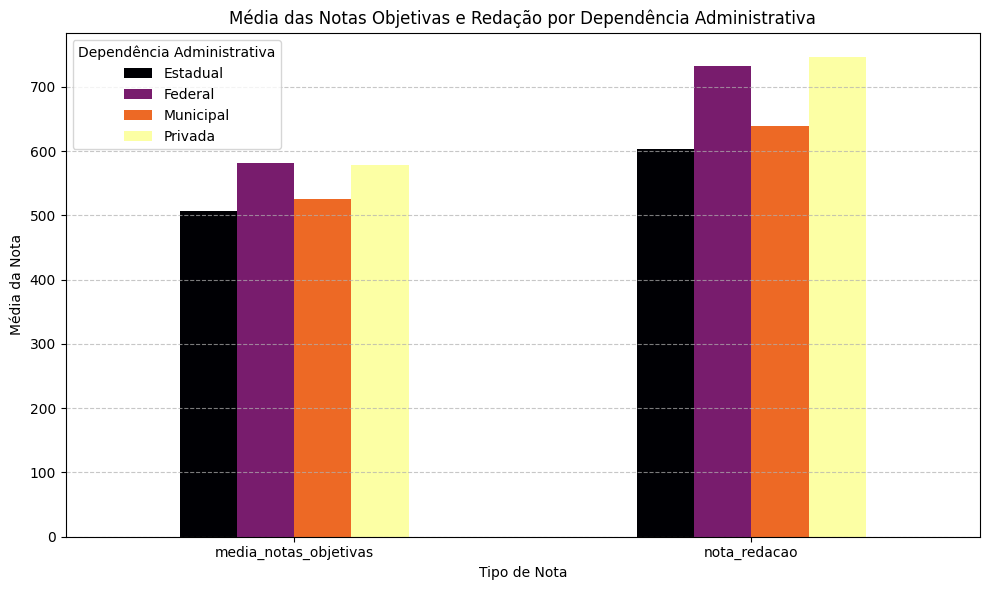


Quando comparadas as médias das provas objetivas entre dependências administrativas,
observa-se um elemento curioso: a pontuação das escolas federais é ligeiramente mais alta
do que das escolas privadas. Quando comparadas as notas das provas de redação,
a pontuação das escolas privadas é maior do que das escolas federais.



dep_adm
Estadual     138177
Federal        3193
Municipal      4316
Privada       68495
Name: dep_adm, dtype: int64

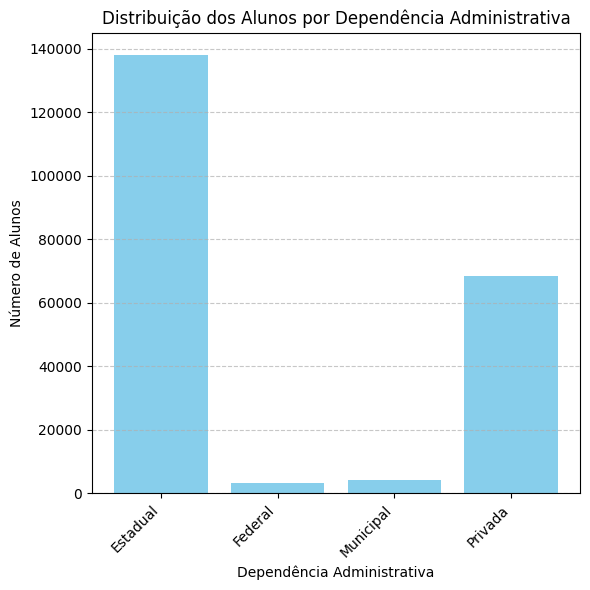



Quando analisados os números absolutos de alunos por dependência administrativa,
nota-se que o número de alunos oriundos de escolas estaduais é muito maior do que o número
das demais dependências administrativas. Ora, essa quantidade enorme de alunos de escolas estaduais
acaba, talvez, por diluir as notas altas, puxando a média para baixo.




In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# Média das notas por Dependência Administrativa
mean_scores_dep_adm = df_enem_sp.groupby('dep_adm')[['media_notas_objetivas', 'nota_redacao']].mean().round(2)
display(mean_scores_dep_adm)

# Transpor o DataFrame para facilitar a plotagem
mean_scores_dep_adm_transposed = mean_scores_dep_adm.transpose()

# Criar o gráfico de barras
plt.figure(figsize=(12, 7))
mean_scores_dep_adm_transposed.plot(kind='bar', figsize=(10, 6), colormap='inferno')
plt.title('Média das Notas Objetivas e Redação por Dependência Administrativa')
plt.xlabel('Tipo de Nota')
plt.ylabel('Média da Nota')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Dependência Administrativa')
plt.tight_layout()
plt.show()

print("""\nQuando comparadas as médias das provas objetivas entre dependências administrativas,
observa-se um elemento curioso: a pontuação das escolas federais é ligeiramente mais alta
do que das escolas privadas. Quando comparadas as notas das provas de redação,
a pontuação das escolas privadas é maior do que das escolas federais.\n""")

# Contagem de escolas por dependência
dep_adm_counts = df_enem_sp.groupby('dep_adm')['dep_adm'].count()
display(dep_adm_counts)

# Plotagem em gráfico de barras
plt.figure(figsize=(6, 6))
plt.bar(dep_adm_counts.index, dep_adm_counts.values, color='skyblue')
plt.title('Distribuição dos Alunos por Dependência Administrativa')
plt.xlabel('Dependência Administrativa')
plt.ylabel('Número de Alunos')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("""
\nQuando analisados os números absolutos de alunos por dependência administrativa,
nota-se que o número de alunos oriundos de escolas estaduais é muito maior do que o número
das demais dependências administrativas. Ora, essa quantidade enorme de alunos de escolas estaduais
acaba, talvez, por diluir as notas altas, puxando a média para baixo.\n
""")

#### Média das notas por Categoria de Escola Privada

,media_notas_objetivas,nota_redacao
cat_esc_priv,,
Comunitária,600.60,784.04
Confessional,554.22,736.14
Filantrópica,582.63,760.51
Particular,578.21,744.65


<Figure size 1200x700 with 0 Axes>

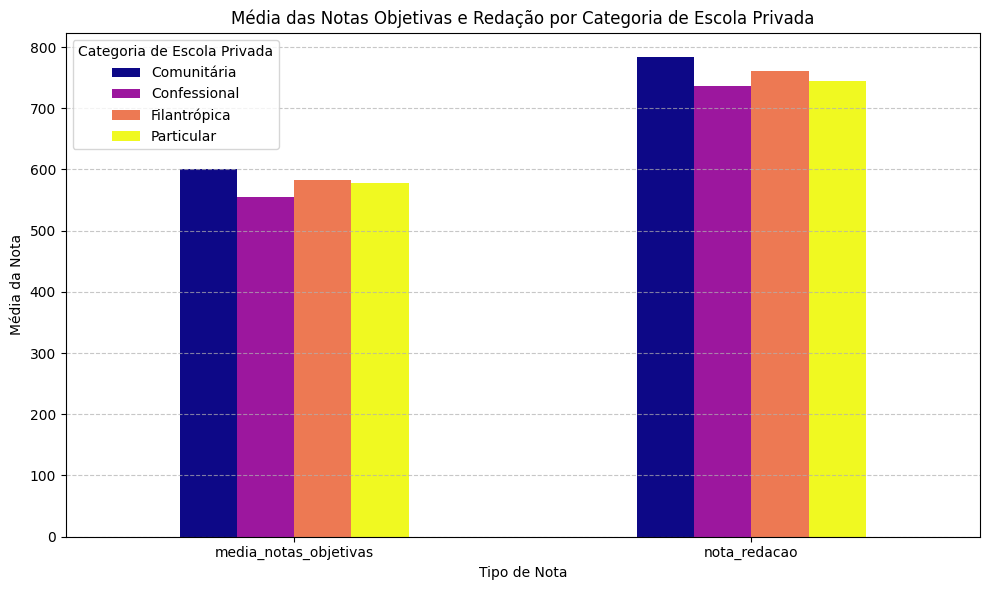



Quando comparadas as médias das provas objetivas e da prova de redação
entre categorias de escola privada, observa-se a mesma sequência, dada por
Comunitária, seguida por Filantrópica, Particular e Confessional.





cat_esc_priv
Comunitária       312
Confessional      917
Filantrópica     9516
Particular      57750
Name: cat_esc_priv, dtype: int64

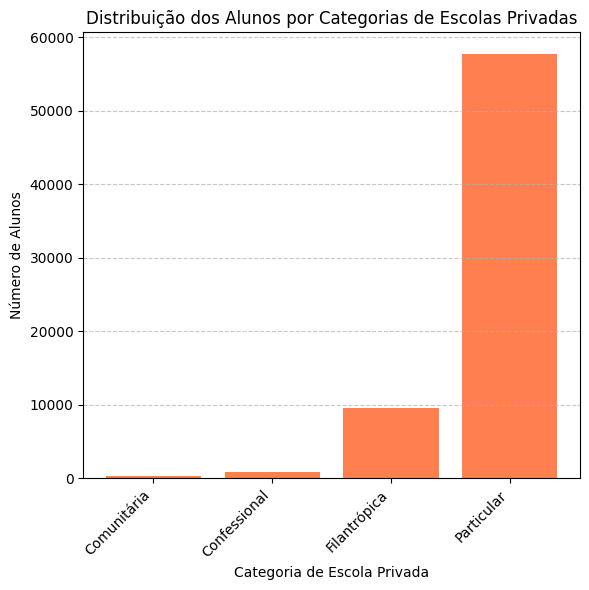



Quando analisados os números absolutos de alunos por categoria de escola privada,
nota-se que o número de alunos oriundos de escolas particulares é muito maior do que o número
de alunos oriundos das demais categorias. Ora, nota-se um padrão, que se aplica a todas as escolas,
exceto nos casos das escolas municipais, das escolas federais - específicamente na prova de redação -
e das escolas confessionais (exceções que validam a regra): pontuações mais altas nas provas são
inversamente proporcionais à quantidade de alunos oriundos de determinado tipo de escola. Os tipos de escola,
supõe-se, não conseguem manter o mesmo padrão de qualidade de ensino; logo, tipos de escola com um menor número
de alunos tendem a obter notas médias mais altas, uma vez que a diluição das notas incide menos no cálculo da média.




In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# Média das notas por Categoria de Escola Privada
mean_scores_cat_esc_priv = df_enem_sp[df_enem_sp['cat_adm'] == 'Privada'].groupby('cat_esc_priv')[['media_notas_objetivas', 'nota_redacao']].mean().round(2)
display(mean_scores_cat_esc_priv)

# Transpor o DataFrame para facilitar a plotagem
mean_scores_cat_esc_priv_transposed = mean_scores_cat_esc_priv.transpose()

# Criar o gráfico de barras
plt.figure(figsize=(12, 7))
mean_scores_cat_esc_priv_transposed.plot(kind='bar', figsize=(10, 6), colormap='plasma')
plt.title('Média das Notas Objetivas e Redação por Categoria de Escola Privada')
plt.xlabel('Tipo de Nota')
plt.ylabel('Média da Nota')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Categoria de Escola Privada')
plt.tight_layout()
plt.show()

print("""\n
Quando comparadas as médias das provas objetivas e da prova de redação
entre categorias de escola privada, observa-se a mesma sequência, dada por
Comunitária, seguida por Filantrópica, Particular e Confessional.
\n
""")

# Contagem de escolas por categoria privada
cat_esc_priv_counts = df_enem_sp[df_enem_sp['cat_adm'] == 'Privada'].groupby('cat_esc_priv')['cat_esc_priv'].count()
display(cat_esc_priv_counts)

# Plotagem em gráfico de barras
plt.figure(figsize=(6, 6))
plt.bar(cat_esc_priv_counts.index, cat_esc_priv_counts.values, color='coral')
plt.title('Distribuição dos Alunos por Categorias de Escolas Privadas')
plt.xlabel('Categoria de Escola Privada')
plt.ylabel('Número de Alunos')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("""
\nQuando analisados os números absolutos de alunos por categoria de escola privada,
nota-se que o número de alunos oriundos de escolas particulares é muito maior do que o número
de alunos oriundos das demais categorias. Ora, nota-se um padrão, que se aplica a todas as escolas,
exceto nos casos das escolas municipais, das escolas federais - específicamente na prova de redação -
e das escolas confessionais (exceções que validam a regra): pontuações mais altas nas provas são
inversamente proporcionais à quantidade de alunos oriundos de determinado tipo de escola. Os tipos de escola,
supõe-se, não conseguem manter o mesmo padrão de qualidade de ensino; logo, tipos de escola com um menor número
de alunos tendem a obter notas médias mais altas, uma vez que a diluição das notas incide menos no cálculo da média.\n
""")

### Nessa segunda seção, apresentam-se alguns dados de interesse a partir do dataset com os dados agregados pelos municípios.

In [96]:
import pandas as pd

# Carregar os dados
df_final = pd.read_csv('data/df_final.csv')
display(df_final.head())
print("\nDados carregados com sucesso!")

,municipio,media_notas,total_participantes,desvio_notas,ipdm,rendimento_domiciliar_per_capita,taxa_ensino_superior_completo,taxa_alfabetizacao
0,São Paulo,535.3,55351,74.7,577,2713.36,27.70,0.974
1,Guarulhos,520.4,6145,67.5,527,1643.73,18.27,0.968
2,Campinas,550.6,5403,77.2,587,2678.60,27.50,0.976
3,São Bernardo do Campo,543.4,4967,72.2,609,2229.41,27.02,0.976
4,São José dos Campos,556.4,4231,77.8,604,2276.81,26.22,0.979



Dados carregados com sucesso!


#### Top 10 municípios com maiores médias das provas objetivas

In [97]:
# Ordenar pela coluna 'media_notas', de maneira decrescente
top_municipios_media = df_final.sort_values(by='media_notas', ascending=False)

# Exibir as 10 primeiras linhas do DataFrame
display(top_municipios_media.head(10))

# Calcular a procentagem dos alunos dos Top 10 municípios que são oriundos de escola privada
print(f"""
Porcentagem de alunos oriundos de escolas privadas nos municípios do Top 10:
  Valinhos: {round(((df_enem_sp[(df_enem_sp['municipio'] == 'Valinhos') & (df_enem_sp['cat_adm'] == 'Privada')].shape[0] / df_enem_sp[df_enem_sp['municipio'] == 'Valinhos'].shape[0]) * 100), 2)}%
  São João da Boa Vista: {round(((df_enem_sp[(df_enem_sp['municipio'] == 'São João da Boa Vista') & (df_enem_sp['cat_adm'] == 'Privada')].shape[0] / df_enem_sp[df_enem_sp['municipio'] == 'São João da Boa Vista'].shape[0]) * 100), 2)}%
  São José dos Campos: {round(((df_enem_sp[(df_enem_sp['municipio'] == 'São José dos Campos') & (df_enem_sp['cat_adm'] == 'Privada')].shape[0] / df_enem_sp[df_enem_sp['municipio'] == 'São José dos Campos'].shape[0]) * 100), 2)}%
  Amparo: {round(((df_enem_sp[(df_enem_sp['municipio'] == 'Amparo') & (df_enem_sp['cat_adm'] == 'Privada')].shape[0] / df_enem_sp[df_enem_sp['municipio'] == 'Amparo'].shape[0]) * 100), 2)}%
  Limeira: {round(((df_enem_sp[(df_enem_sp['municipio'] == 'Limeira') & (df_enem_sp['cat_adm'] == 'Privada')].shape[0] / df_enem_sp[df_enem_sp['municipio'] == 'Limeira'].shape[0]) * 100), 2)}%
  Boituva: {round(((df_enem_sp[(df_enem_sp['municipio'] == 'Boituva') & (df_enem_sp['cat_adm'] == 'Privada')].shape[0] / df_enem_sp[df_enem_sp['municipio'] == 'Boituva'].shape[0]) * 100), 2)}%
  Ribeirão Preto: {round(((df_enem_sp[(df_enem_sp['municipio'] == 'Ribeirão Preto') & (df_enem_sp['cat_adm'] == 'Privada')].shape[0] / df_enem_sp[df_enem_sp['municipio'] == 'Ribeirão Preto'].shape[0]) * 100), 2)}%
  Votuporanga: {round(((df_enem_sp[(df_enem_sp['municipio'] == 'Votuporanga') & (df_enem_sp['cat_adm'] == 'Privada')].shape[0] / df_enem_sp[df_enem_sp['municipio'] == 'Votuporanga'].shape[0]) * 100), 2)}%
  Botucatu: {round(((df_enem_sp[(df_enem_sp['municipio'] == 'Botucatu') & (df_enem_sp['cat_adm'] == 'Privada')].shape[0] / df_enem_sp[df_enem_sp['municipio'] == 'Botucatu'].shape[0]) * 100), 2)}%
  Guaratinguetá: {round(((df_enem_sp[(df_enem_sp['municipio'] == 'Guaratinguetá') & (df_enem_sp['cat_adm'] == 'Privada')].shape[0] / df_enem_sp[df_enem_sp['municipio'] == 'Guaratinguetá'].shape[0]) * 100), 2)}%
\nObserva-se que, dentre os 10 municípios com as médias mais altas, 8 deles possuem porcentagem de alunos
oriundos de escolas privadas superior à média estadual (31,98%).
""")

,municipio,media_notas,total_participantes,desvio_notas,ipdm,rendimento_domiciliar_per_capita,taxa_ensino_superior_completo,taxa_alfabetizacao
50,Valinhos,572.4,801,81.7,614,3127.28,31.58,0.980
82,São João da Boa Vista,565.0,466,71.1,590,1961.78,22.58,0.973
4,São José dos Campos,556.4,4231,77.8,604,2276.81,26.22,0.979
83,Amparo,556.1,463,72.1,591,1986.75,19.23,0.968
30,Limeira,554.7,1365,69.5,588,1932.42,17.70,0.972
130,Boituva,554.1,249,69.9,587,1819.01,19.86,0.970
8,Ribeirão Preto,553.6,3473,77.5,566,2507.29,25.87,0.980
92,Votuporanga,552.5,420,69.4,594,1789.36,20.49,0.967
56,Botucatu,552.2,704,73.2,568,1991.29,24.28,0.974
65,Guaratinguetá,551.6,588,69.6,546,1872.42,21.29,0.977



Porcentagem de alunos oriundos de escolas privadas nos municípios do Top 10:
  Valinhos: 53.68%
  São João da Boa Vista: 54.94%
  São José dos Campos: 46.06%
  Amparo: 21.81%
  Limeira: 32.01%
  Boituva: 49.0%
  Ribeirão Preto: 53.38%
  Votuporanga: 34.05%
  Botucatu: 51.99%
  Guaratinguetá: 25.51%

Observa-se que, dentre os 10 municípios com as médias mais altas, 8 deles possuem porcentagem de alunos
oriundos de escolas privadas superior à média estadual (31,98%).



#### Explorando Mapas do Estado de São Paulo usando GeoPandas

Para visualizar e manipular dados geoespaciais, utilizaremos a biblioteca `geopandas`.

In [98]:
# Instalar geopandas
%pip install geopandas

print("Geopandas instalado com sucesso!")

Note: you may need to restart the kernel to use updated packages.
Geopandas instalado com sucesso!


##### Agora, vamos importar as bibliotecas necessárias (`geopandas` e `matplotlib.pyplot`) e carregar um arquivo geoespacial que represente os municípios do estado de São Paulo.

In [99]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Caminho para o seu arquivo shapefile dos municípios de São Paulo
map_file_path = 'data/municipios_sp.shp'

try:
    # Carregar o arquivo geoespacial
    gdf_sp = gpd.read_file(map_file_path)
    print(f"Dados geoespaciais de São Paulo carregados com sucesso de: {map_file_path}")

    # Exibir as primeiras linhas do GeoDataFrame
    display(gdf_sp.head())
except FileNotFoundError:
    print(f"Erro: O arquivo '{map_file_path}' não foi encontrado. Por favor, verifique o caminho e o nome do arquivo.")
except Exception as e:
    print(f"Ocorreu um erro ao carregar o arquivo geoespacial: {e}")

Dados geoespaciais de São Paulo carregados com sucesso de: data/municipios_sp.shp


,CD_MUN,NM_MUN,CD_RGI,NM_RGI,CD_RGINT,NM_RGINT,CD_UF,NM_UF,SIGLA_UF,CD_REGIAO,NM_REGIAO,SIGLA_RG,CD_CONCURB,NM_CONCURB,AREA_KM2,geometry
0,3543402,Ribeirão Preto,350031,Ribeirão Preto,3508,Ribeirão Preto,35,São Paulo,SP,3,Sudeste,SE,3543402,Ribeirão Preto/SP,650.916,"POLYGON ((-47.75591 -21.27076, -47.756 -21.270..."
1,3518859,Guatapará,350031,Ribeirão Preto,3508,Ribeirão Preto,35,São Paulo,SP,3,Sudeste,SE,NaN,NaN,413.653,"POLYGON ((-47.88985 -21.49211, -47.88914 -21.4..."
2,3518206,Guararapes,350022,Araçatuba,3506,Araçatuba,35,São Paulo,SP,3,Sudeste,SE,NaN,NaN,955.637,"POLYGON ((-50.87363 -21.48917, -50.87333 -21.4..."
3,3510005,Cândido Mota,350014,Assis,3504,Marília,35,São Paulo,SP,3,Sudeste,SE,NaN,NaN,595.811,"POLYGON ((-50.34526 -22.91116, -50.3461 -22.91..."
4,3502606,Aparecida d'Oeste,350028,Jales,3507,São José do Rio Preto,35,São Paulo,SP,3,Sudeste,SE,NaN,NaN,179.004,"POLYGON ((-50.86389 -20.52668, -50.86428 -20.5..."


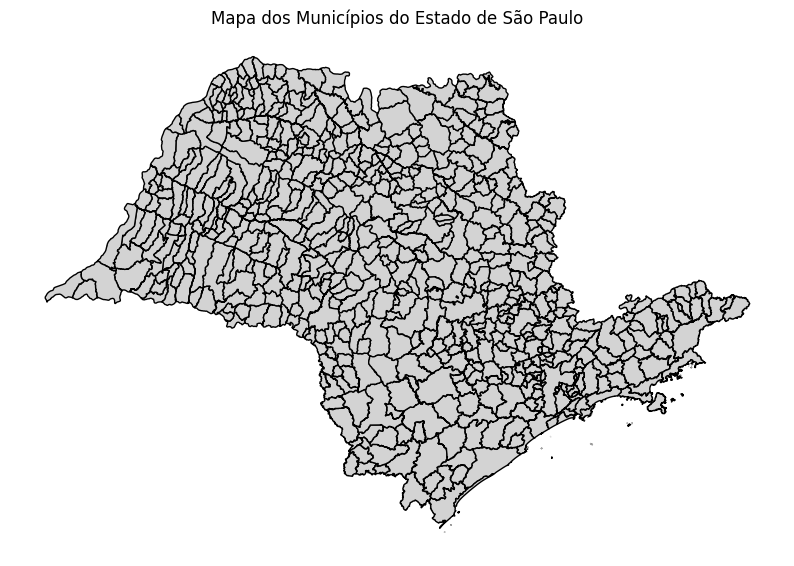

In [100]:
# Visualizar o mapa dos municípios de São Paulo
if 'gdf_sp' in locals() and not gdf_sp.empty:
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    gdf_sp.plot(ax=ax, color='lightgray', edgecolor='black')
    ax.set_title('Mapa dos Municípios do Estado de São Paulo')
    ax.set_axis_off() # Remover eixos para uma visualização de mapa mais limpa
    plt.show()
else:
    print("Não foi possível plotar o mapa. Verifique se 'gdf_sp' foi carregado corretamente.")

##### Visualização da Média das Notas por Município em Mapa

Vamos agora visualizar a média das notas no mapa de São Paulo, colorindo os municípios de acordo com seus valores de `media_notas`.

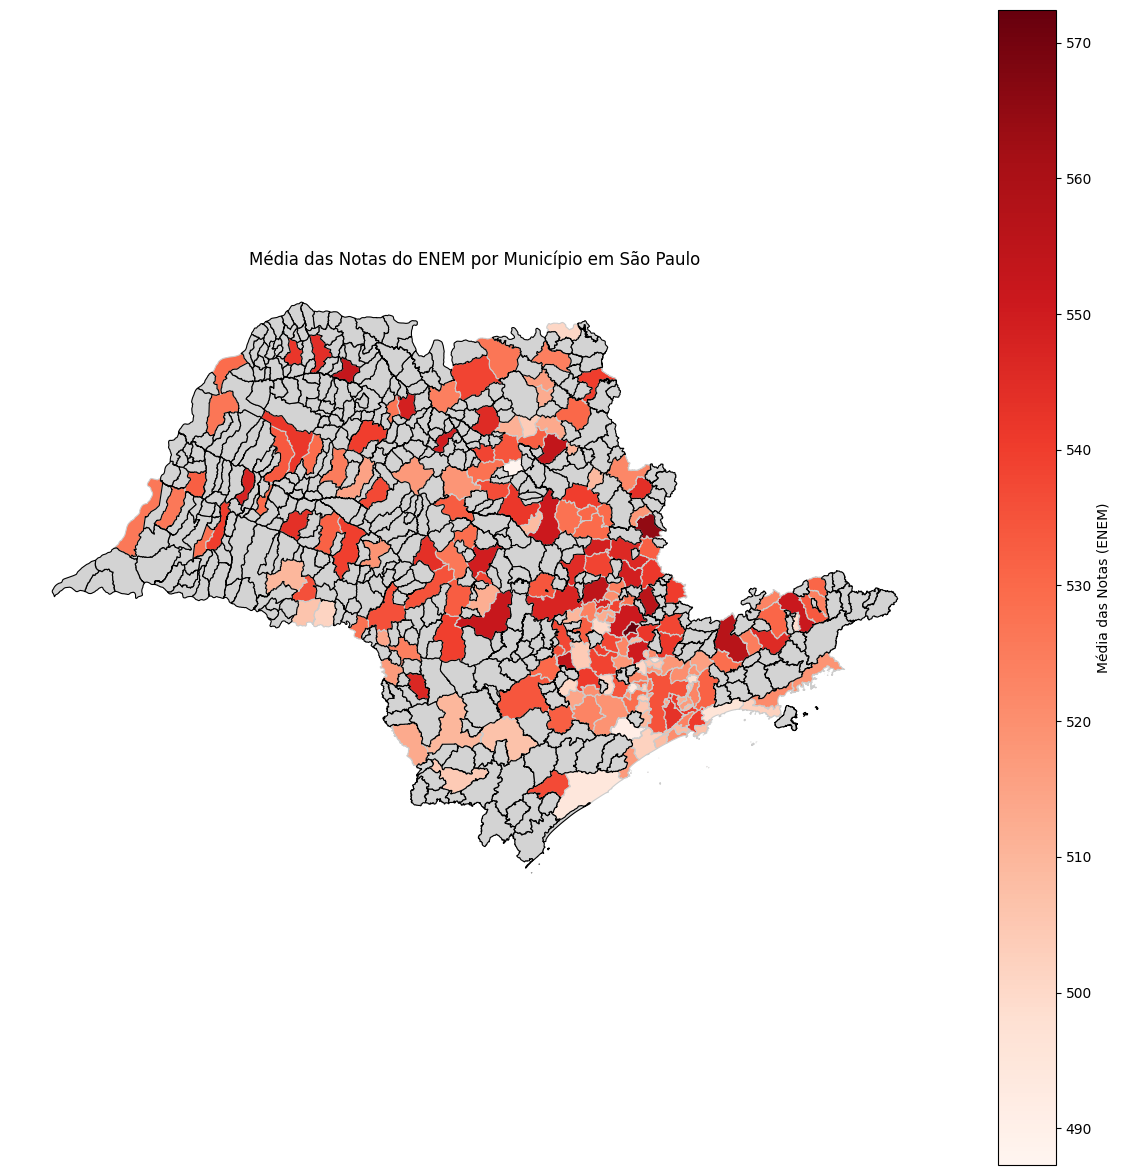


Observa-se uma concentração de municípios com médias mais altas
na região sul do estado.



In [101]:
import matplotlib.pyplot as plt

# Criar cópias dos DataFrames para evitar SettingWithCopyWarning
df_final_copy = df_final.copy()
gdf_sp_copy = gdf_sp.copy()

# Padronizar os nomes dos municípios para o merge (ex: remover acentos e converter para minúsculas)
df_final_copy['municipio_clean'] = df_final_copy['municipio'].str.lower().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')
gdf_sp_copy['NM_MUN'] = gdf_sp_copy['NM_MUN'].str.lower().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

# Realizar o merge
gdf_merged = gdf_sp_copy.merge(df_final_copy, left_on='NM_MUN', right_on='municipio_clean', how='left')

# Plotar o mapa com a média das notas
# Usar missing_kwds para estilizar municípios sem dados
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
gdf_merged.plot(
    column='media_notas',
    cmap='Reds',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "Média das Notas (ENEM)"},
    missing_kwds={
        "color": "lightgray",
        "edgecolor": "black",
        "label": "Sem Dados"
    }
)
ax.set_title('Média das Notas do ENEM por Município em São Paulo')
ax.set_axis_off()
plt.show()

print("""\nObserva-se uma concentração de municípios com médias mais altas
na região sul do estado.
""")


##### Visualização do IPDM por Município em Mapa

Vamos agora visualizar o IPDM no mapa de São Paulo, colorindo os municípios de acordo com seus valores de `ipdm`.

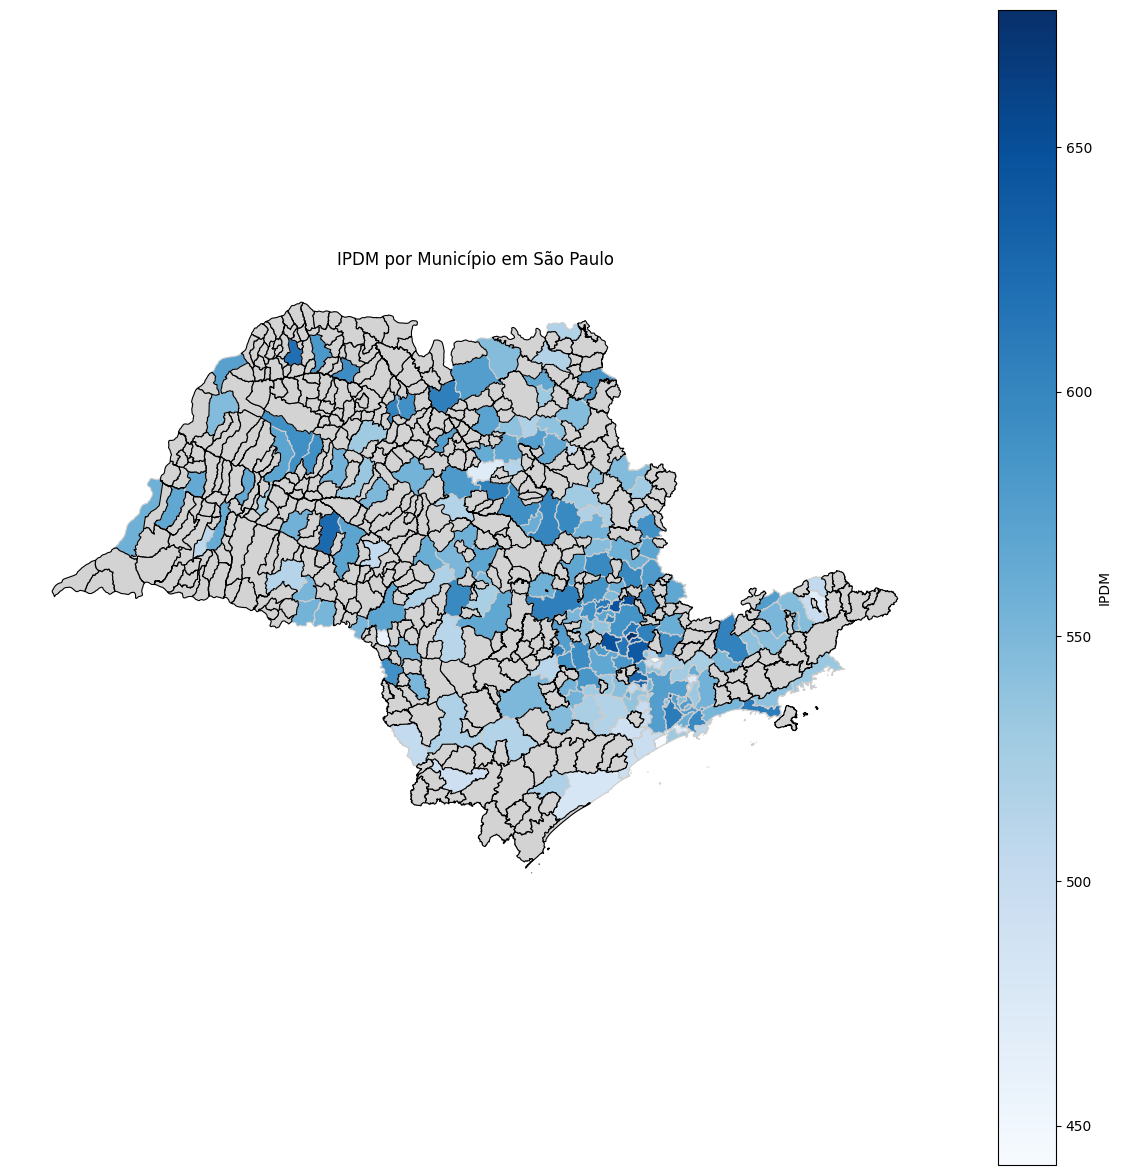


Observa-se uma concentração de municípios com o IPDM mais altos,
também, na região sul do estado.



In [102]:
import matplotlib.pyplot as plt

# Plotar o mapa com o IDPM
# Usar missing_kwds para estilizar municípios sem dados
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
gdf_merged.plot(
    column='ipdm',
    cmap='Blues',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "IPDM"},
    missing_kwds={
        "color": "lightgray",
        "edgecolor": "black",
        "label": "Sem Dados"
    }
)
ax.set_title('IPDM por Município em São Paulo')
ax.set_axis_off()
plt.show()

print("""\nObserva-se uma concentração de municípios com o IPDM mais altos,
também, na região sul do estado.
""")

##### Visualização do Rendimento Domiciliar per capita por Município em Mapa

Vamos agora visualizar o Rendimento Domiciliar per capita no mapa de São Paulo, colorindo os municípios de acordo com seus valores de `rendimento_domiciliar_per_capita`.

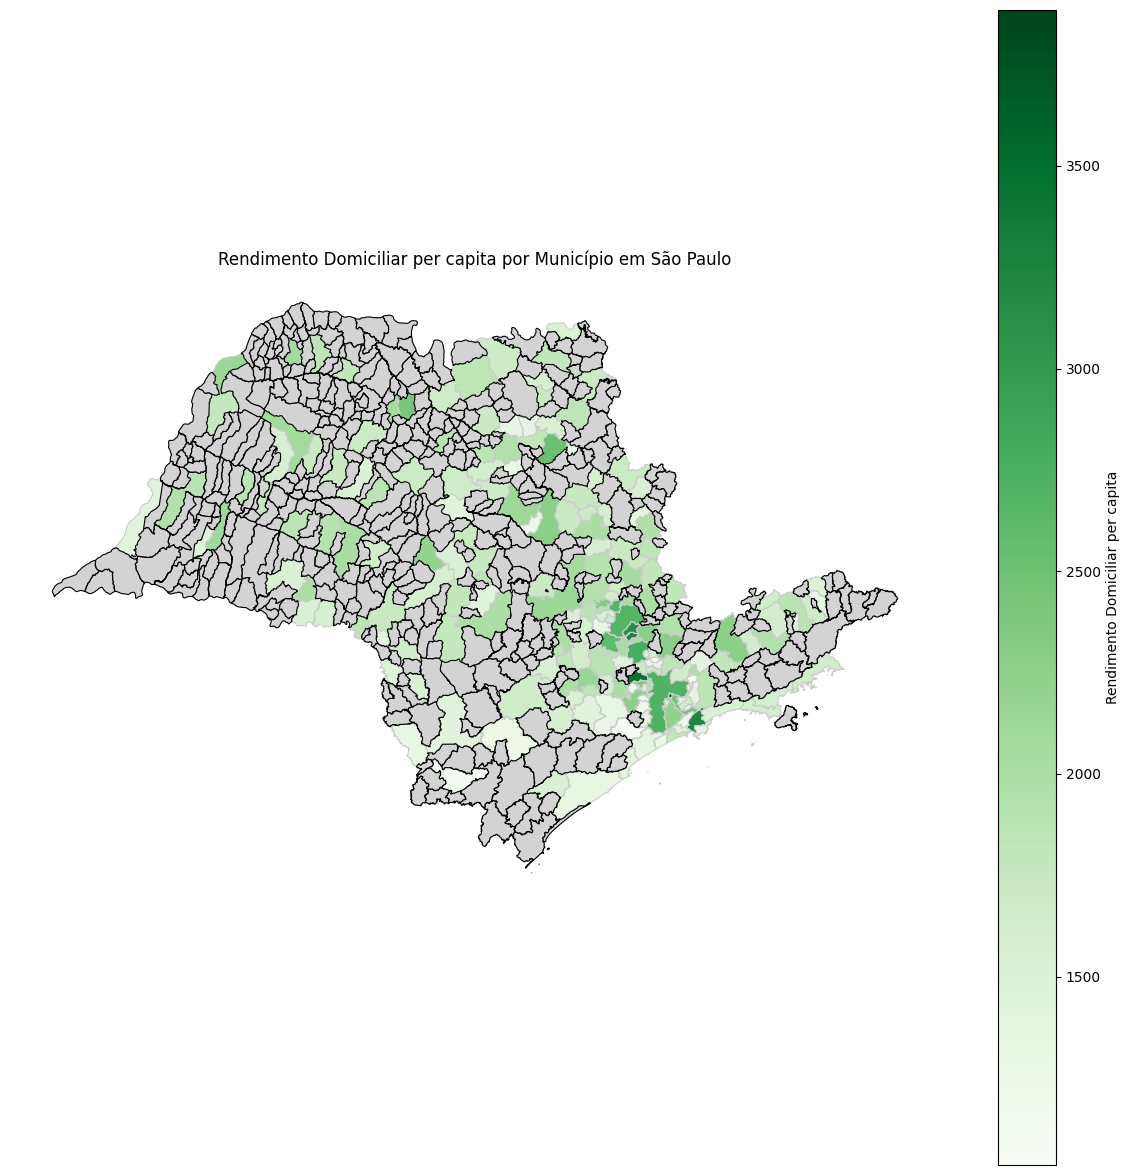


Observa-se uma pulverização de municípios com o Rendimento Domiciliar per capita
mais baixos, com alguns poucos municípios, localizados na região sul do estado,
coloridos com tonalidades mais escuras.



In [103]:
import matplotlib.pyplot as plt

# Plotar o mapa com o Rendimento Domiciliar per capita
# Usar missing_kwds para estilizar municípios sem dados
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
gdf_merged.plot(
    column='rendimento_domiciliar_per_capita',
    cmap='Greens',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "Rendimento Domiciliar per capita"},
    missing_kwds={
        "color": "lightgray",
        "edgecolor": "black",
        "label": "Sem Dados"
    }
)
ax.set_title('Rendimento Domiciliar per capita por Município em São Paulo')
ax.set_axis_off()
plt.show()

print("""\nObserva-se uma pulverização de municípios com o Rendimento Domiciliar per capita
mais baixos, com alguns poucos municípios, localizados na região sul do estado,
coloridos com tonalidades mais escuras.
""")

##### Visualização da Taxa de Adultos com Ensino Superior Completo por Município em Mapa

Vamos agora visualizar a Taxa de Adultos com Ensino Superior Completo no mapa de São Paulo, colorindo os municípios de acordo com seus valores de `taxa_ensino_superior_completo`.

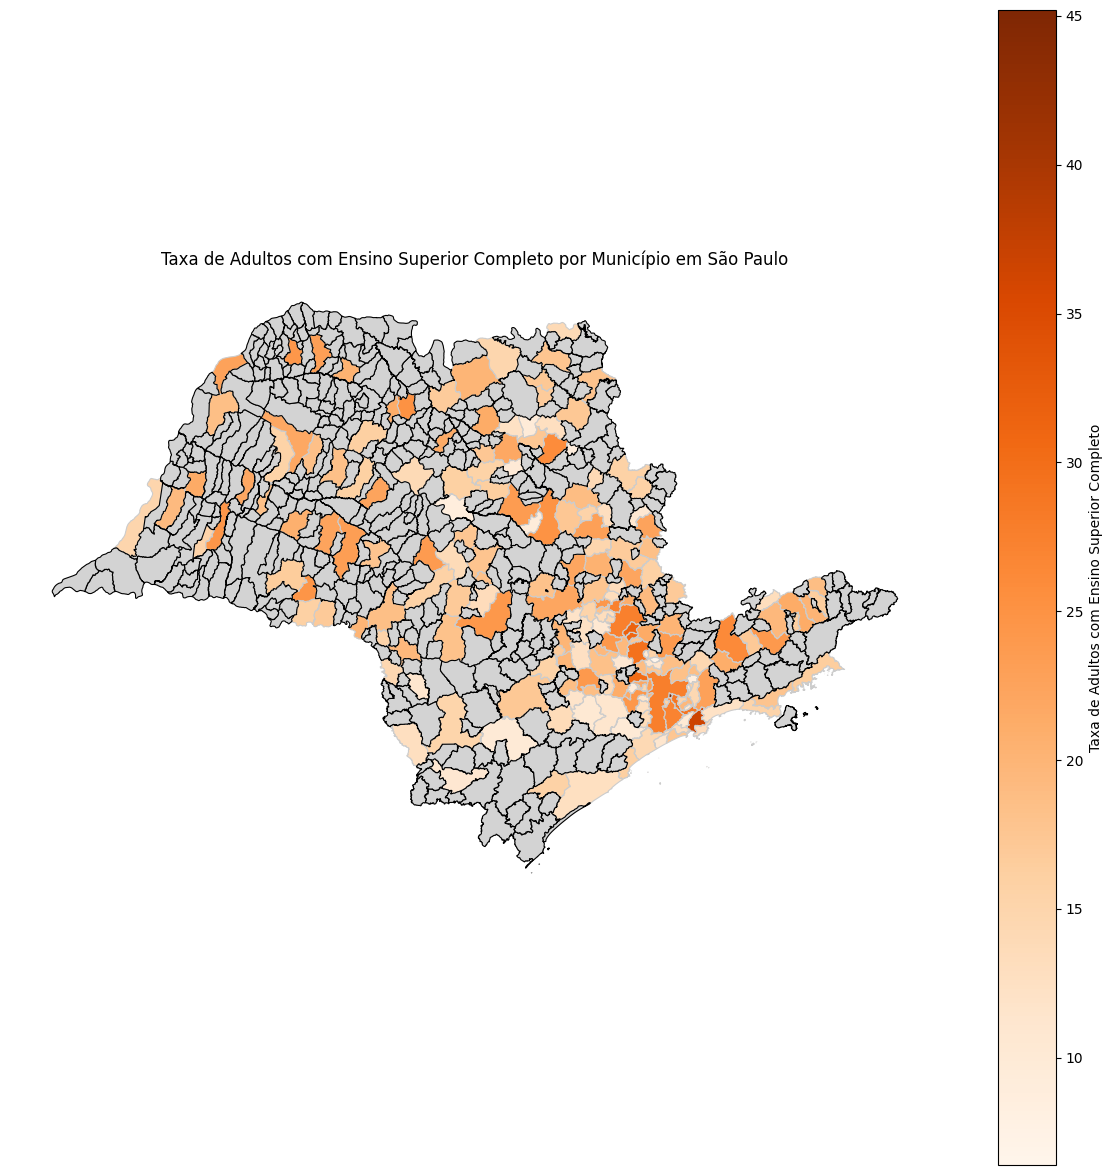


Observa-se uma pulverização de municípios com a Taxa de Adultos com Ensino
Superior Completo mais baixas, com alguns poucos municípios, localizados na região sul do estado,
coloridos com tonalidades mais escuras.



In [104]:
import matplotlib.pyplot as plt

# Plotar o mapa com o Taxa de Adultos com Ensino Superior Completo
# Usar missing_kwds para estilizar municípios sem dados
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
gdf_merged.plot(
    column='taxa_ensino_superior_completo',
    cmap='Oranges',
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "Taxa de Adultos com Ensino Superior Completo"},
    missing_kwds={
        "color": "lightgray",
        "edgecolor": "black",
        "label": "Sem Dados"
    }
)
ax.set_title('Taxa de Adultos com Ensino Superior Completo por Município em São Paulo')
ax.set_axis_off()
plt.show()

print("""\nObserva-se uma pulverização de municípios com a Taxa de Adultos com Ensino
Superior Completo mais baixas, com alguns poucos municípios, localizados na região sul do estado,
coloridos com tonalidades mais escuras.
""")

##### Os dados de `total de participantes` e de `taxa de alfabetização` não foram plotados nos mapas, pois não levam à nenhuma conclusão.

No primeiro caso, São Paulo, o município com mais participantes, possui, em relação ao segundo, Guarulhos, quase 10 vezes mais participantes; assim, São Paulo fica sendo o único município colorido com tonalidade mais escura, de modo que os outros 199 municípios ficam indistinguíveis.

No segundo caso, como a diferença do primeiro ao último município é de apenas 5 pontos, quase todos os municípios sao coloridos com tonalidades médias, dificultando a distinção entre eles.

#### Correlações entre variáveis

In [105]:
# Criar correlações entre as variáveis de interesse
correlations = df_final[['media_notas', 'ipdm', 'rendimento_domiciliar_per_capita', 'taxa_alfabetizacao', 'taxa_ensino_superior_completo']].corr(method='pearson')

print("Correlação entre a média das notas e os indicadores do Censo:")
display(correlations['media_notas'].drop('media_notas').to_frame().T)

Correlação entre a média das notas e os indicadores do Censo:


,ipdm,rendimento_domiciliar_per_capita,taxa_alfabetizacao,taxa_ensino_superior_completo
media_notas,0.529047,0.621788,0.557357,0.664085


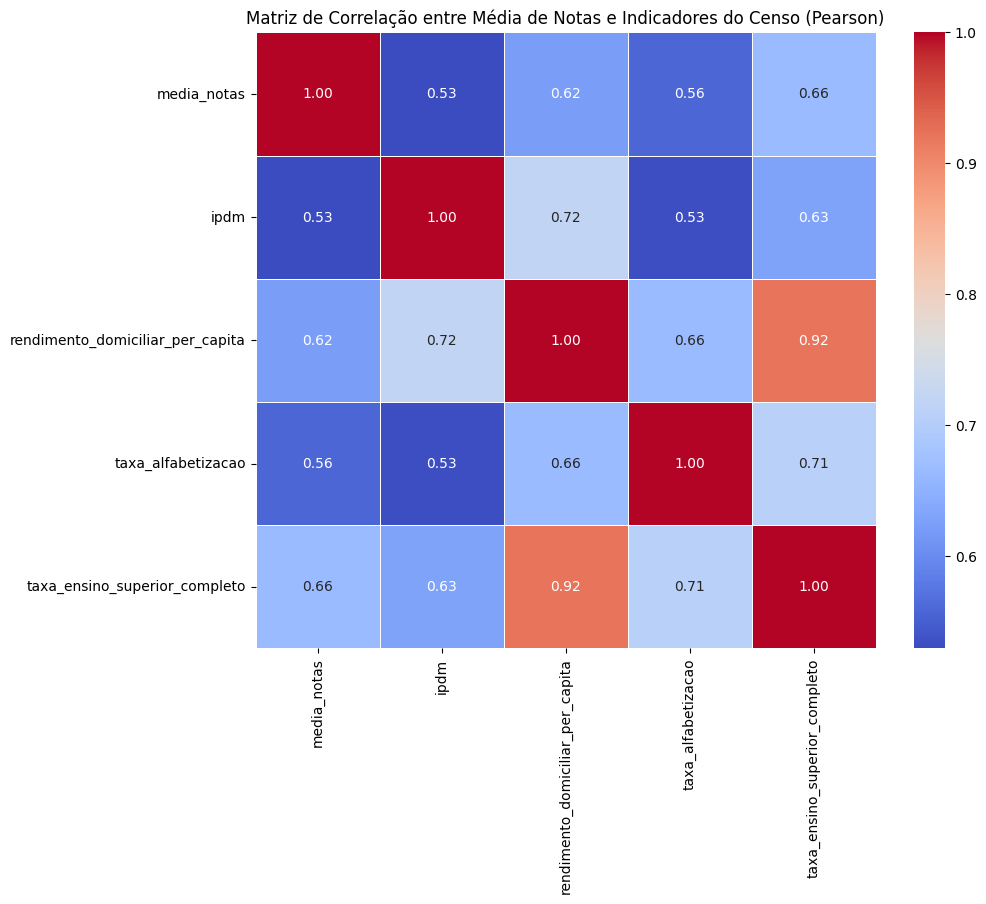



Observa-se, com base no mapa de calor, que as variáveis rendimento_domiciliar_per_capita
e taxa_ensino_superior_completo são altamente correlacionadas entre si.





In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar o heatmap para as correlações dos indicadores do Censo com a média das notas
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação entre Média de Notas e Indicadores do Censo (Pearson)')
plt.show()

print("""
\nObserva-se, com base no mapa de calor, que as variáveis rendimento_domiciliar_per_capita
e taxa_ensino_superior_completo são altamente correlacionadas entre si.
\n
""")

#### Gráficos de dispersão correlacionando `media_notas` e outras variáveis

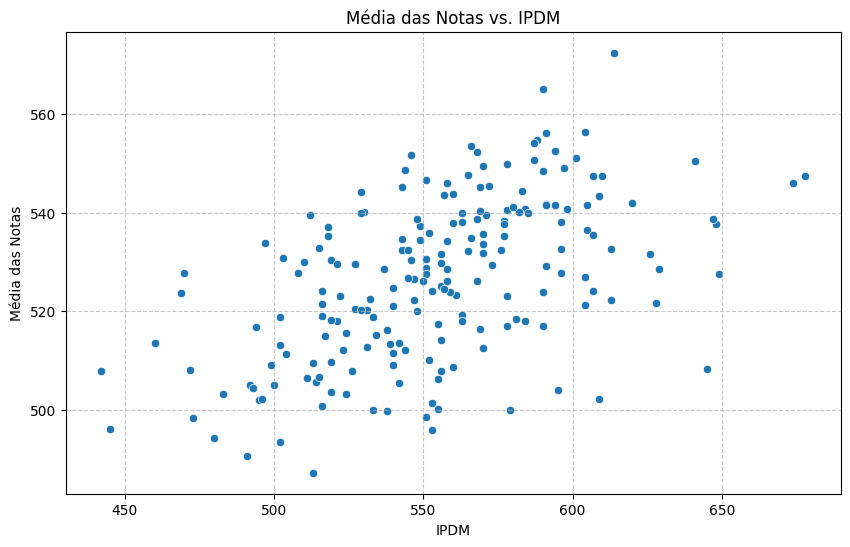

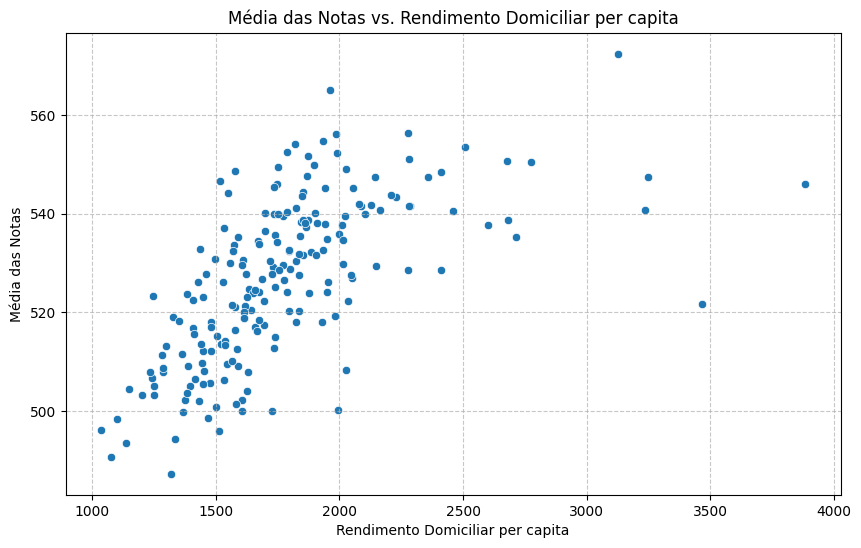

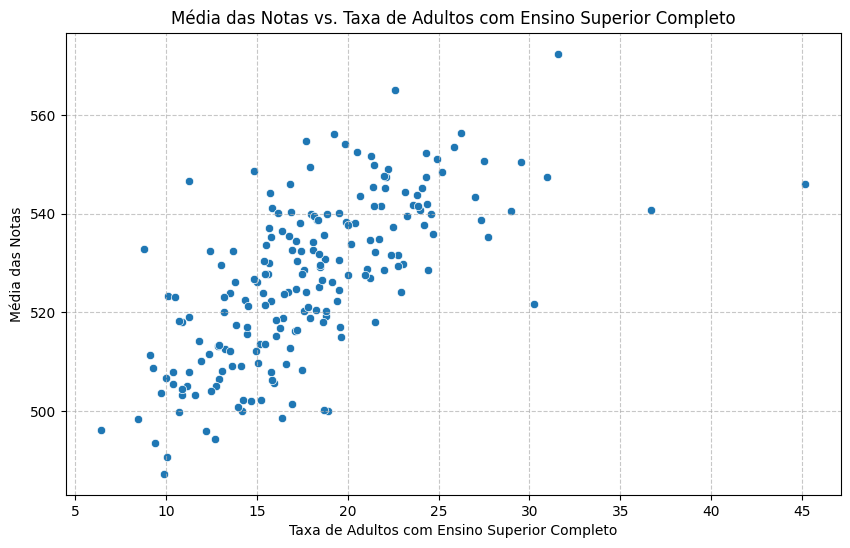

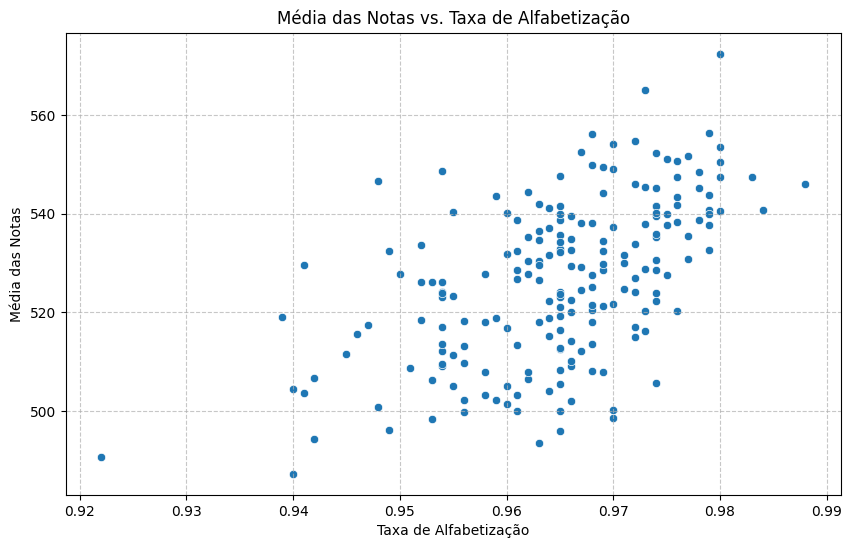



Observa-se que, grosso modo, os 4 indicadores do Censo comportam-se de maneira
positiva moderada a forte quando correlacionados com a média das notas.





In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='ipdm', y='media_notas', data=df_final)
plt.title('Média das Notas vs. IPDM')
plt.xlabel('IPDM')
plt.ylabel('Média das Notas')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='rendimento_domiciliar_per_capita', y='media_notas', data=df_final)
plt.title('Média das Notas vs. Rendimento Domiciliar per capita')
plt.xlabel('Rendimento Domiciliar per capita')
plt.ylabel('Média das Notas')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='taxa_ensino_superior_completo', y='media_notas', data=df_final)
plt.title('Média das Notas vs. Taxa de Adultos com Ensino Superior Completo')
plt.xlabel('Taxa de Adultos com Ensino Superior Completo')
plt.ylabel('Média das Notas')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='taxa_alfabetizacao', y='media_notas', data=df_final)
plt.title('Média das Notas vs. Taxa de Alfabetização')
plt.xlabel('Taxa de Alfabetização')
plt.ylabel('Média das Notas')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("""
\nObserva-se que, grosso modo, os 4 indicadores do Censo comportam-se de maneira
positiva moderada a forte quando correlacionados com a média das notas.
\n
""")

### Nessa terceira seção, finalmente, ocupa-se da aplicação e comparação dos algoritmos de *Machine learning*.

Utiliza-se, também, técnicas para a otimização de alguns dos principais hiperparâmetros.

#### 3.1 Preparação dos Dados para aplicação dos algoritmos

Primeiro, vamos definir nossas variáveis independentes (features) e a variável dependente (target) - utilizando os indicadores do censo como features e a média das notas como target.

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Definindo as features (X) e o target (y)
X = df_final[['ipdm', 'rendimento_domiciliar_per_capita',
                           'taxa_alfabetizacao', 'taxa_ensino_superior_completo']]
y = df_final['media_notas']

# Dividindo os dados em conjuntos de treinamento e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializando o StandardScaler
scaler = StandardScaler()

# Padronizando os dados de treinamento
X_train = scaler.fit_transform(X_train)

# Padronizando os dados de teste usando o scaler treinado no conjunto de treino
X_test = scaler.transform(X_test)

print("Dados de treinamento e teste padronizados com sucesso!\n")

print(f"Tamanho do conjunto de treinamento: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras")

Dados de treinamento e teste padronizados com sucesso!

Tamanho do conjunto de treinamento: 160 amostras
Tamanho do conjunto de teste: 40 amostras


#### Regressão Linear

##### 3.2 Treinamento do Modelo de Regressão Linear

Agora, vamos treinar o modelo de regressão linear usando os dados de treinamento.

In [109]:
from sklearn.linear_model import LinearRegression

# Inicializando e treinando o modelo de Regressão Linear
model_rl = LinearRegression()
model_rl.fit(X_train, y_train)

print("Modelo de Regressão Linear treinado com sucesso!\n")
print(f"Coeficientes do modelo: {model_rl.coef_}")
print(f"Intercepto do modelo: {model_rl.intercept_}")

Modelo de Regressão Linear treinado com sucesso!

Coeficientes do modelo: [ 3.64494929 -2.30784648  0.44435242 10.62569164]
Intercepto do modelo: 525.45875


##### 3.3 Avaliação do Modelo

Vamos avaliar o desempenho do modelo nos dados de teste usando métricas como o Erro Médio Quadrático (Mean Squared Error - MSE) e o Coeficiente de Determinação (R²).

In [110]:
from sklearn.metrics import mean_squared_error, r2_score

# Fazendo previsões no conjunto de teste
y_pred_rl = model_rl.predict(X_test)

# Avaliando o modelo
mse = mean_squared_error(y_test, y_pred_rl)
r2 = r2_score(y_test, y_pred_rl)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Mean Squared Error (MSE): 216.05
R-squared (R²): 0.25


##### 3.4 Visualização das Previsões vs. Valores Reais

Podemos visualizar as previsões do modelo em comparação com os valores reais para ter uma ideia do seu ajuste.

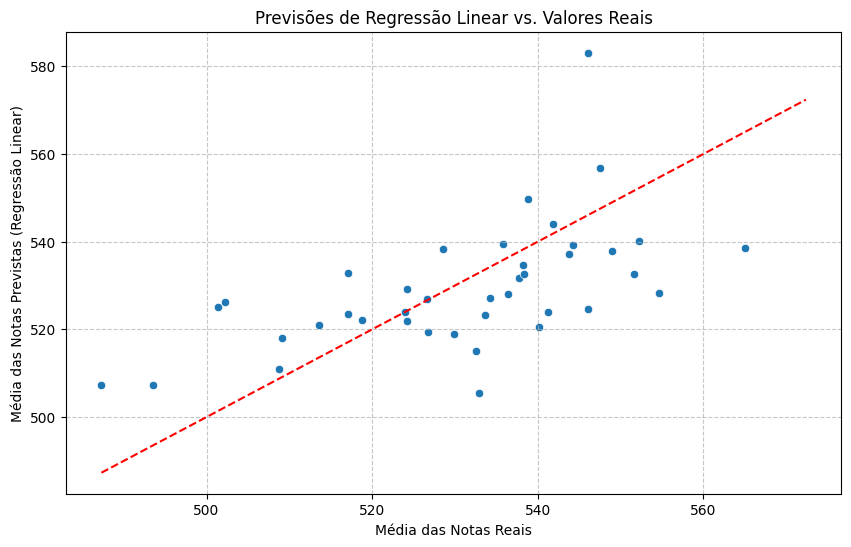

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rl)
plt.xlabel('Média das Notas Reais')
plt.ylabel('Média das Notas Previstas (Regressão Linear)')
plt.title('Previsões de Regressão Linear vs. Valores Reais')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Linha de 45 graus para referência
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Regressão Ridge

##### 3.5 Testando a Regressão Ridge

Agora vamos aplicar o algoritmo de Regressão Ridge para ver como ele se comporta em comparação com o modelo de Regressão Linear. A Regressão Ridge é uma forma de regressão linear que inclui regularização L2. Essa técnica ajuda a prevenir o *overfitting*, adicionando uma penalidade proporcional ao quadrado da magnitude dos coeficientes.

In [112]:
from sklearn.linear_model import Ridge

# Inicializando e treinando o modelo Ridge Regression
# O parâmetro 'alpha' controla a força da regularização (valor padrão é 1.0)
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)

print("Modelo Ridge Regressor treinado com sucesso!")

Modelo Ridge Regressor treinado com sucesso!


##### 3.6 Avaliação da Regressão Ridge

Agora, vamos avaliar o desempenho da Regressão Ridge usando as mesmas métricas (MSE e R²) e visualização.

In [113]:
from sklearn.metrics import mean_squared_error, r2_score

# Fazendo previsões no conjunto de teste
y_pred_ridge = ridge_model.predict(X_test)

# Avaliando o modelo Ridge
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Regressor - Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"Ridge Regressor - R-squared (R²): {r2_ridge:.2f}")

Ridge Regressor - Mean Squared Error (MSE): 214.37
Ridge Regressor - R-squared (R²): 0.26


##### 3.7 Visualização das Previsões do Ridge Regressor vs. Valores Reais

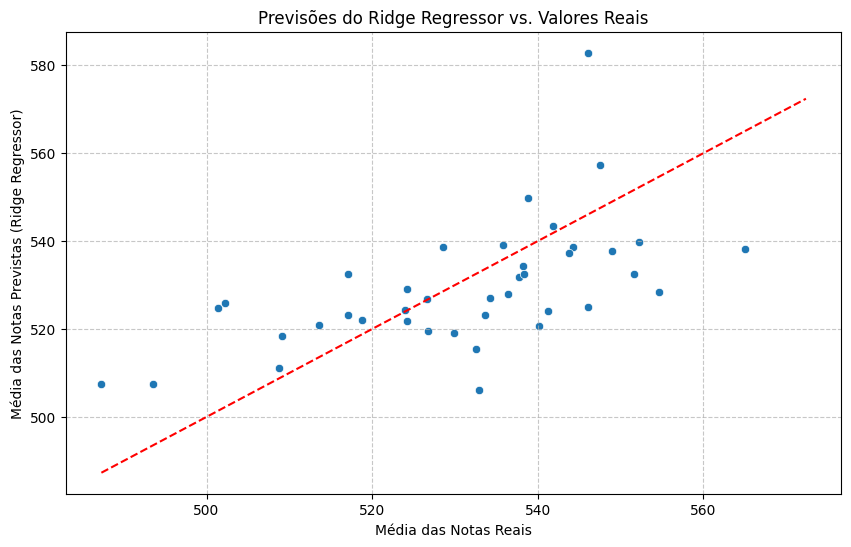

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_ridge)
plt.xlabel('Média das Notas Reais')
plt.ylabel('Média das Notas Previstas (Ridge Regressor)')
plt.title('Previsões do Ridge Regressor vs. Valores Reais')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Linha de 45 graus para referência
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Regressão Ridge otimizada (GridSearchCV)

##### 3.8 Otimização de Hiperparâmetros com GridSearchCV para Regressão Ridge

Vamos usar o `GridSearchCV` para encontrar o melhor valor para o parâmetro `alpha` do nosso modelo de Regressão Ridge. O `alpha` controla a força da regularização L2.

In [115]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Definir o espaço de busca dos hiperparâmetros para alpha
param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

# Inicializar o modelo Ridge Regression
ridge_base = Ridge(random_state=42)

# Configurar o GridSearchCV
grid_search_ridge = GridSearchCV(
    estimator=ridge_base,
    param_grid=param_grid_ridge,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Ajustar o GridSearchCV aos dados de treinamento
grid_search_ridge.fit(X_train, y_train)

print("Grid Search para Ridge concluído!\n")
print(f"Melhores hiperparâmetros para Ridge: {grid_search_ridge.best_params_} - ou seja, o valor padrão.")
print(f"Melhor R-squared na validação cruzada para Ridge: {grid_search_ridge.best_score_:.2f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits


Grid Search para Ridge concluído!

Melhores hiperparâmetros para Ridge: {'alpha': 1.0} - ou seja, o valor padrão.
Melhor R-squared na validação cruzada para Ridge: 0.47


##### 3.9 Avaliação do Melhor Modelo Ridge Otimizado

Agora, vamos avaliar o melhor modelo Ridge encontrado pelo `GridSearchCV` no conjunto de teste.

In [116]:
from sklearn.metrics import mean_squared_error, r2_score

# Obter o melhor modelo Ridge
best_ridge_model = grid_search_ridge.best_estimator_

# Fazer previsões no conjunto de teste com o melhor modelo Ridge
y_pred_best_ridge = best_ridge_model.predict(X_test)

# Avaliar o melhor modelo Ridge
mse_best_ridge = mean_squared_error(y_test, y_pred_best_ridge)
r2_best_ridge = r2_score(y_test, y_pred_best_ridge)

print(f"Melhor Ridge (GridSearchCV) - Mean Squared Error (MSE): {mse_best_ridge:.2f}")
print(f"Melhor Ridge (GridSearchCV) - R-squared (R²): {r2_best_ridge:.2f}")

print("\nComparação com o modelo Ridge sem otimização:")
print(f"MSE sem otimização: {mse_ridge:.2f}")
print(f"R² sem otimização: {r2_ridge:.2f}")

print("""\nAmbos são identicos porque o melhor alpha encontrado na otimização
é o mesmo alpha empregado no modelo sem otimização.""")

Melhor Ridge (GridSearchCV) - Mean Squared Error (MSE): 214.37
Melhor Ridge (GridSearchCV) - R-squared (R²): 0.26

Comparação com o modelo Ridge sem otimização:
MSE sem otimização: 214.37
R² sem otimização: 0.26

Ambos são identicos porque o melhor alpha encontrado na otimização
é o mesmo alpha empregado no modelo sem otimização.


##### 3.10 Visualização das Previsões do Melhor Ridge Otimizado vs. Valores Reais

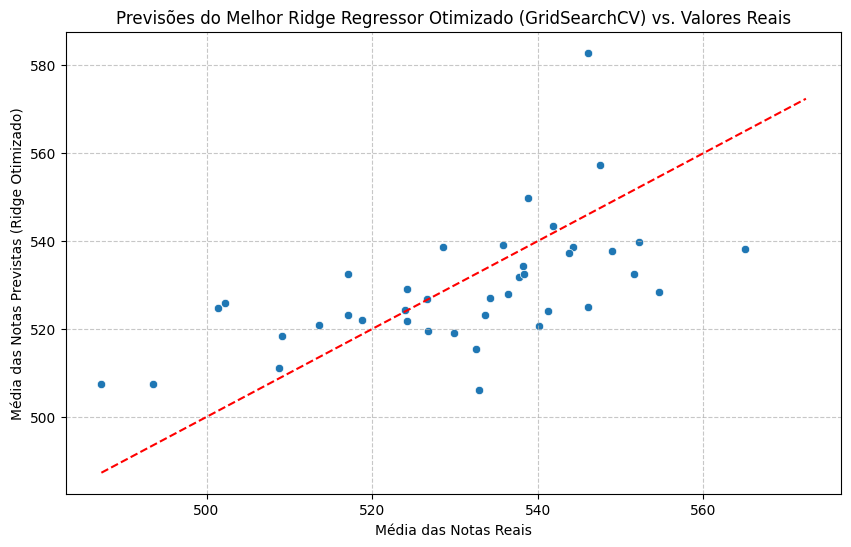


O gráfico é idêntico ao do modelo sem a otimização, uma vez que o melhor alpha é o padrão.


In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_best_ridge)
plt.xlabel('Média das Notas Reais')
plt.ylabel('Média das Notas Previstas (Ridge Otimizado)')
plt.title('Previsões do Melhor Ridge Regressor Otimizado (GridSearchCV) vs. Valores Reais')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Linha de 45 graus para referência
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\nO gráfico é idêntico ao do modelo sem a otimização, uma vez que o melhor alpha é o padrão.")

#### Random Forest Regressor

##### 3.11 Testando o Random Forest Regressor

Vamos aplicar o algoritmo de Random Forest Regressor para ver como ele se compara com a Regressão Ridge.


In [118]:
from sklearn.ensemble import RandomForestRegressor

# Inicializando e treinando o modelo Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # n_estimators é o número de árvores na floresta
rf_model.fit(X_train, y_train)

print("Modelo Random Forest Regressor treinado com sucesso!")

Modelo Random Forest Regressor treinado com sucesso!


##### 3.12 Avaliação do Modelo Random Forest

Agora, vamos avaliar o desempenho do Random Forest Regressor usando as mesmas métricas (MSE e R²) e visualização.

In [119]:
# Fazendo previsões no conjunto de teste com Random Forest
y_pred_rf = rf_model.predict(X_test)

# Avaliando o modelo Random Forest
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"Random Forest - R-squared (R²): {r2_rf:.2f}")

print("\nComparação com o modelo Ridge com GridSearchCV:")
print(f"\nMelhor Ridge (GridSearchCV) - Mean Squared Error (MSE): {mse_best_ridge:.2f}")
print(f"Melhor Ridge (GridSearchCV) - R-squared (R²): {r2_best_ridge:.2f}")

Random Forest - Mean Squared Error (MSE): 138.61
Random Forest - R-squared (R²): 0.52

Comparação com o modelo Ridge com GridSearchCV:

Melhor Ridge (GridSearchCV) - Mean Squared Error (MSE): 214.37
Melhor Ridge (GridSearchCV) - R-squared (R²): 0.26


##### 3.13 Visualização das Previsões do Random Forest vs. Valores Reais

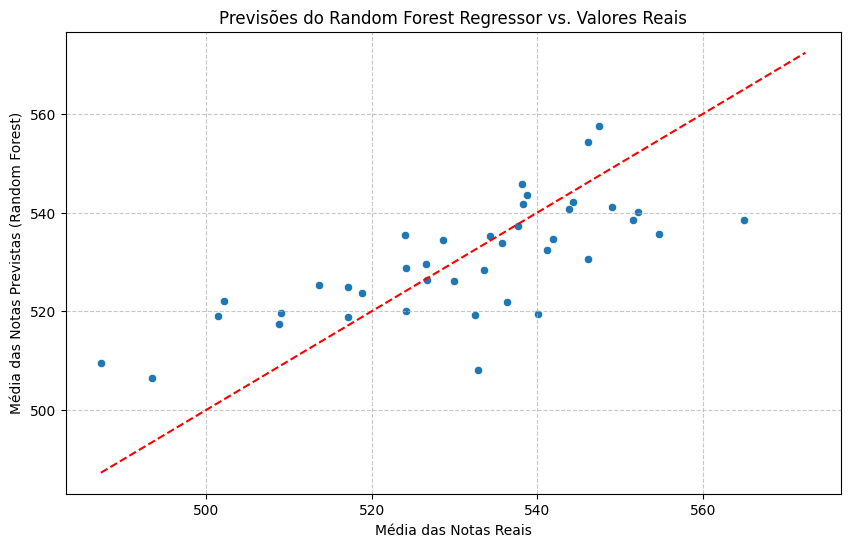

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.xlabel('Média das Notas Reais')
plt.ylabel('Média das Notas Previstas (Random Forest)')
plt.title('Previsões do Random Forest Regressor vs. Valores Reais')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Linha de 45 graus para referência
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Random Forest otimizado (GridSearchCV)

##### 3.14 Otimização de Hiperparâmetros com GridSearchCV para Random Forest

Vamos usar o `GridSearchCV` para encontrar a melhor combinação de hiperparâmetros para o nosso modelo Random Forest. Esta técnica explora sistematicamente todas as combinações de hiperparâmetros fornecidas em uma grade.

In [121]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Definir o espaço de busca dos hiperparâmetros
param_grid = {
    'n_estimators': [50, 100, 150], # Número de árvores na floresta
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Inicializar o modelo Random Forest
rf = RandomForestRegressor(random_state=42)

# Configurar o GridSearchCV
# cv=5 significa 5-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)

# Ajustar o GridSearchCV aos dados de treinamento
grid_search.fit(X_train, y_train)

print("Grid Search concluído!")
print(f"Melhores hiperparâmetros: {grid_search.best_params_}")
print(f"Melhor R-squared na validação cruzada: {grid_search.best_score_:.2f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Grid Search concluído!
Melhores hiperparâmetros: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 150}
Melhor R-squared na validação cruzada: 0.42


##### 3.15 Avaliação do Melhor Modelo Random Forest Otimizado

Após encontrar os melhores hiperparâmetros, vamos avaliar o modelo com esses parâmetros no conjunto de teste.

In [122]:
# Obter o melhor modelo
best_rf_model = grid_search.best_estimator_

# Fazer previsões no conjunto de teste com o melhor modelo
y_pred_best_rf = best_rf_model.predict(X_test)

# Avaliar o melhor modelo
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print(f"Melhor Random Forest (Otimizado) - Mean Squared Error (MSE): {mse_best_rf:.2f}")
print(f"Melhor Random Forest (Otimizado) - R-squared (R²): {r2_best_rf:.2f}")

print("\nComparação com o modelo Random Forest sem otimização:")
print(f"MSE sem otimização: {mse_rf:.2f}")
print(f"R² sem otimização: {r2_rf:.2f}")

Melhor Random Forest (Otimizado) - Mean Squared Error (MSE): 134.76
Melhor Random Forest (Otimizado) - R-squared (R²): 0.54

Comparação com o modelo Random Forest sem otimização:
MSE sem otimização: 138.61
R² sem otimização: 0.52


##### 3.16 Visualização das Previsões do Melhor Random Forest Otimizado vs. Valores Reais

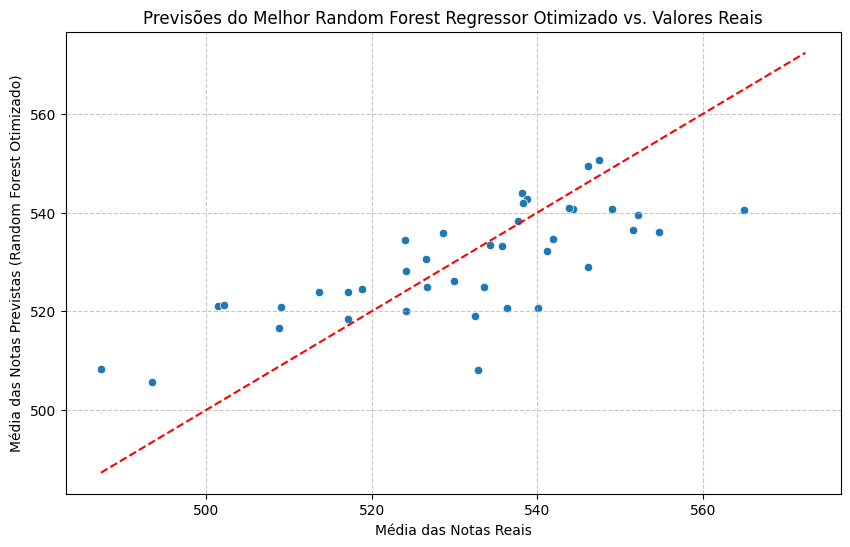

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_best_rf)
plt.xlabel('Média das Notas Reais')
plt.ylabel('Média das Notas Previstas (Random Forest Otimizado)')
plt.title('Previsões do Melhor Random Forest Regressor Otimizado vs. Valores Reais')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Linha de 45 graus para referência
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Random Forest otimizado (RandomizedSearchCV)

##### 3.17 Otimização de Hiperparâmetros com RandomizedSearchCV para Random Forest

Vamos usar o `RandomizedSearchCV` para encontrar uma boa combinação de hiperparâmetros para o nosso modelo Random Forest de forma mais eficiente. Esta técnica amostra aleatoriamente um número fixo de combinações de hiperparâmetros de um determinado espaço.

In [124]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Definir o espaço de busca dos hiperparâmetros com distribuições
param_distributions = {
    'n_estimators': randint(low=20, high=200), # Número de árvores na floresta
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': randint(low=2, high=20),
    'min_samples_leaf': randint(low=1, high=10)
}

# Inicializar o modelo Random Forest
rf = RandomForestRegressor(random_state=42)

# Configurar o RandomizedSearchCV
# n_iter: número de combinações de hiperparâmetros a serem amostradas
# cv=5 significa 5-fold cross-validation
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=50, # Experimente 50 combinações aleatórias
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Ajustar o RandomizedSearchCV aos dados de treinamento padronizados
random_search.fit(X_train, y_train)

print("Randomized Search concluído!\n")
print(f"Melhores hiperparâmetros: {random_search.best_params_}")
print(f"Melhor R-squared na validação cruzada: {random_search.best_score_:.2f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Randomized Search concluído!

Melhores hiperparâmetros: {'max_depth': 20, 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 141}
Melhor R-squared na validação cruzada: 0.45


##### 3.18 Avaliação do Melhor Modelo Random Forest Otimizado com RandomizedSearchCV

Após encontrar os melhores hiperparâmetros, vamos avaliar o modelo com esses parâmetros no conjunto de teste.

In [125]:
# Obter o melhor modelo
best_rf_random_model = random_search.best_estimator_

# Fazer previsões no conjunto de teste com o melhor modelo
y_pred_best_rf_random = best_rf_random_model.predict(X_test)

# Avaliar o melhor modelo
mse_best_rf_random = mean_squared_error(y_test, y_pred_best_rf_random)
r2_best_rf_random = r2_score(y_test, y_pred_best_rf_random)

print(f"Melhor Random Forest (RandomizedSearchCV) - Mean Squared Error (MSE): {mse_best_rf_random:.2f}")
print(f"Melhor Random Forest (RandomizedSearchCV) - R-squared (R²): {r2_best_rf_random:.2f}")

print("\nComparação com o modelo Random Forest com GridSearchCV:")
print(f"MSE GridSearchCV: {mse_best_rf:.2f}")
print(f"R² GridSearchCV: {r2_best_rf:.2f}")

print("\nComparação com o modelo Random Forest sem otimização:")
print(f"MSE sem otimização: {mse_rf:.2f}")
print(f"R² sem otimização: {r2_rf:.2f}")

print("""
\nCabe observar que os resultados obtidos com o GridSearchCV se mostram superiores
aos obtidos com o RandomizedSearchCV.
""")

Melhor Random Forest (RandomizedSearchCV) - Mean Squared Error (MSE): 138.07
Melhor Random Forest (RandomizedSearchCV) - R-squared (R²): 0.52

Comparação com o modelo Random Forest com GridSearchCV:
MSE GridSearchCV: 134.76
R² GridSearchCV: 0.54

Comparação com o modelo Random Forest sem otimização:
MSE sem otimização: 138.61
R² sem otimização: 0.52


Cabe observar que os resultados obtidos com o GridSearchCV se mostram superiores
aos obtidos com o RandomizedSearchCV.



##### 3.19 Visualização das Previsões do Melhor Random Forest Otimizado com RandomizedSearchCV vs. Valores Reais

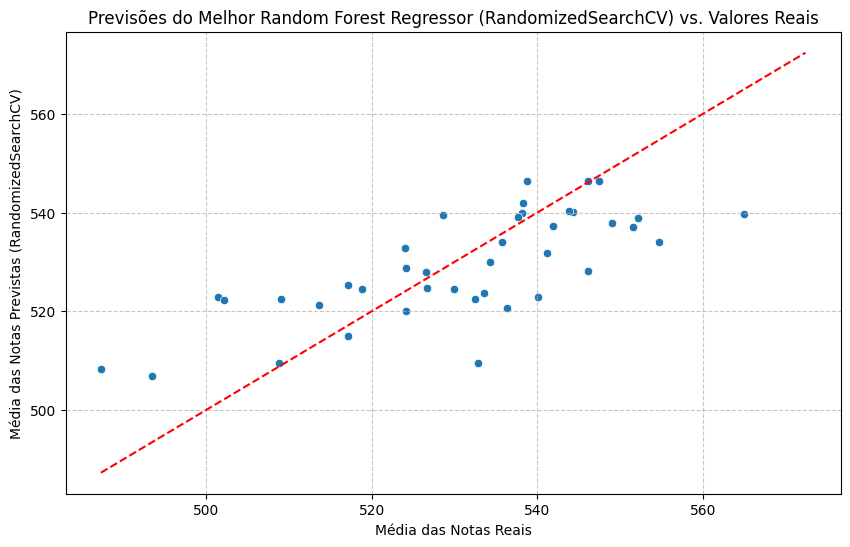

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_best_rf_random)
plt.xlabel('Média das Notas Reais')
plt.ylabel('Média das Notas Previstas (RandomizedSearchCV)')
plt.title('Previsões do Melhor Random Forest Regressor (RandomizedSearchCV) vs. Valores Reais')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Linha de 45 graus para referência
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### XGBoost Regressor

##### 3.20 Testando o XGBoost Regressor

Agora vamos aplicar o algoritmo XGBoost Regressor para ver como ele se comporta em comparação com o Random Forest.

In [127]:
import xgboost as xgb

# Inicializando e treinando o modelo XGBoost
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

print("Modelo XGBoost Regressor treinado com sucesso!")

Modelo XGBoost Regressor treinado com sucesso!


##### 3.21 Avaliação do Modelo XGBoost

Vamos avaliar o desempenho do XGBoost Regressor usando as mesmas métricas (MSE e R²) e visualização.

In [128]:
# Fazendo previsões no conjunto de teste com XGBoost
y_pred_xgb = xgb_model.predict(X_test)

# Avaliando o modelo XGBoost
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost - Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"XGBoost - R-squared (R²): {r2_xgb:.2f}")

print("\nComparação com o modelo Random Forest com GridSearchCV:")
print(f"Random Forest - MSE GridSearchCV: {mse_best_rf:.2f}")
print(f"Random Forest - R² GridSearchCV: {r2_best_rf:.2f}")

XGBoost - Mean Squared Error (MSE): 158.80
XGBoost - R-squared (R²): 0.45

Comparação com o modelo Random Forest com GridSearchCV:
Random Forest - MSE GridSearchCV: 134.76
Random Forest - R² GridSearchCV: 0.54


##### 3.22 Visualização das Previsões do XGBoost vs. Valores Reais

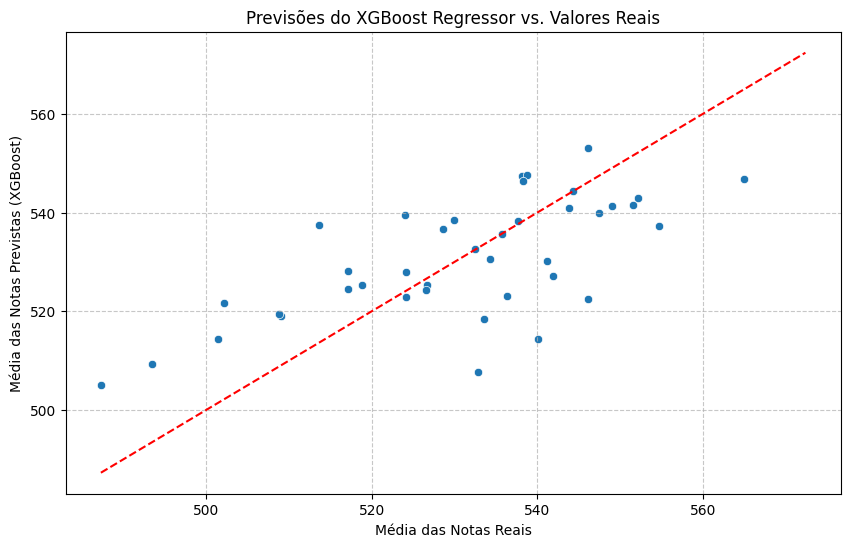

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_xgb)
plt.xlabel('Média das Notas Reais')
plt.ylabel('Média das Notas Previstas (XGBoost)')
plt.title('Previsões do XGBoost Regressor vs. Valores Reais')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Linha de 45 graus para referência
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### XGBoost otimizado (GridSearchCV)

##### 3.23 Otimização de Hiperparâmetros com GridSearchCV para XGBoost Regressor

Vamos usar o `GridSearchCV` para otimizar o XGBoost Regressor, procurando a melhor combinação de hiperparâmetros de forma exaustiva.

In [130]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# Definir o espaço de busca dos hiperparâmetros para XGBoost
param_grid_xgb = {
    'n_estimators': [50, 100, 200],  # Número de árvores
    'learning_rate': [0.01, 0.1, 0.2], # Taxa de aprendizado
    'max_depth': [3, 5, 7],        # Profundidade máxima da árvore
    'subsample': [0.7, 0.9, 1.0],    # Fração de amostras para o crescimento das árvores
    'colsample_bytree': [0.7, 0.9, 1.0] # Fração de features para o crescimento das árvores
}

# Inicializar o modelo XGBoost
xgb_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Configurar o GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Ajustar o GridSearchCV aos dados de treinamento
grid_search_xgb.fit(X_train, y_train)

print("Grid Search para XGBoost concluído!\n")
print(f"Melhores hiperparâmetros para XGBoost: {grid_search_xgb.best_params_}")
print(f"Melhor R-squared na validação cruzada para XGBoost: {grid_search_xgb.best_score_:.2f}")

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Grid Search para XGBoost concluído!

Melhores hiperparâmetros para XGBoost: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}
Melhor R-squared na validação cruzada para XGBoost: 0.46


##### 3.24 Avaliação do Melhor Modelo XGBoost Otimizado com GridSearchCV

Agora, vamos avaliar o melhor modelo XGBoost encontrado pelo `GridSearchCV` no conjunto de teste.

In [131]:
from sklearn.metrics import mean_squared_error, r2_score

# Obter o melhor modelo XGBoost
best_xgb_grid_model = grid_search_xgb.best_estimator_

# Fazer previsões no conjunto de teste com o melhor modelo XGBoost
y_pred_best_xgb_grid = best_xgb_grid_model.predict(X_test)

# Avaliar o melhor modelo XGBoost
mse_best_xgb_grid = mean_squared_error(y_test, y_pred_best_xgb_grid)
r2_best_xgb_grid = r2_score(y_test, y_pred_best_xgb_grid)

print(f"Melhor XGBoost (GridSearchCV) - Mean Squared Error (MSE): {mse_best_xgb_grid:.2f}")
print(f"Melhor XGBoost (GridSearchCV) - R-squared (R²): {r2_best_xgb_grid:.2f}")

print("\nComparação com o modelo XGBoost sem otimização:")
print(f"MSE sem otimização: {mse_xgb:.2f}")
print(f"R² sem otimização: {r2_xgb:.2f}")

print("""
\nCuriosamente, a otimização do XGBoost teve efeito contrário,
já que o MSE sofreu um leve aumento.
""")

print("\nComparação com o modelo Random Forest com GridSearchCV:")
print(f"Random Forest - MSE GridSearchCV: {mse_best_rf:.2f}")
print(f"Random Forest - R² GridSearchCV: {r2_best_rf:.2f}")

Melhor XGBoost (GridSearchCV) - Mean Squared Error (MSE): 167.37
Melhor XGBoost (GridSearchCV) - R-squared (R²): 0.42

Comparação com o modelo XGBoost sem otimização:
MSE sem otimização: 158.80
R² sem otimização: 0.45


Curiosamente, a otimização do XGBoost teve efeito contrário,
já que o MSE sofreu um leve aumento.


Comparação com o modelo Random Forest com GridSearchCV:
Random Forest - MSE GridSearchCV: 134.76
Random Forest - R² GridSearchCV: 0.54


##### 3.25 Visualização das Previsões do Melhor XGBoost Otimizado (GridSearchCV) vs. Valores Reais

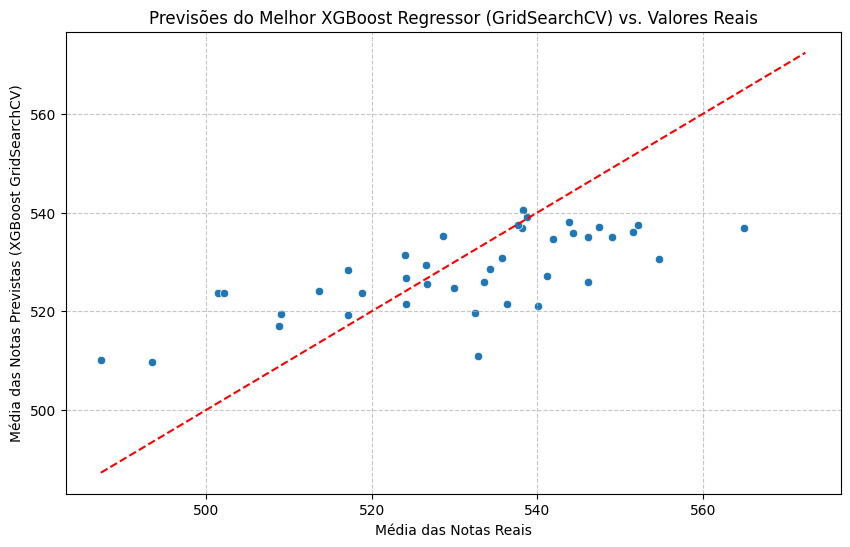

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_best_xgb_grid)
plt.xlabel('Média das Notas Reais')
plt.ylabel('Média das Notas Previstas (XGBoost GridSearchCV)')
plt.title('Previsões do Melhor XGBoost Regressor (GridSearchCV) vs. Valores Reais')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Linha de 45 graus para referência
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### XGBoost otimizado (RandomizedSearchCV)

##### 3.26 Otimização de Hiperparâmetros com RandomizedSearchCV para XGBoost Regressor

Vamos usar o `RandomizedSearchCV` para otimizar o XGBoost Regressor, procurando a melhor combinação de hiperparâmetros.

In [133]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Definir o espaço de busca dos hiperparâmetros para XGBoost
param_distributions_xgb = {
    'n_estimators': randint(low=50, high=300),  # Número de árvores
    'learning_rate': uniform(loc=0.01, scale=0.2), # Taxa de aprendizado
    'max_depth': randint(low=3, high=10),        # Profundidade máxima da árvore
    'subsample': uniform(loc=0.6, scale=0.4),    # Fração de amostras para o crescimento das árvores
    'colsample_bytree': uniform(loc=0.6, scale=0.4) # Fração de features para o crescimento das árvores
}

# Inicializar o modelo XGBoost
xgb_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Configurar o RandomizedSearchCV
# n_iter: número de combinações de hiperparâmetros a serem amostradas
# cv=5 significa 5-fold cross-validation
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions_xgb,
    n_iter=50, # Experimente 50 combinações aleatórias
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Ajustar o RandomizedSearchCV aos dados de treinamento
random_search_xgb.fit(X_train, y_train)

print("Randomized Search para XGBoost concluído!\n")
print(f"Melhores hiperparâmetros para XGBoost: {random_search_xgb.best_params_}")
print(f"Melhor R-squared na validação cruzada para XGBoost: {random_search_xgb.best_score_:.2f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Randomized Search para XGBoost concluído!

Melhores hiperparâmetros para XGBoost: {'colsample_bytree': np.float64(0.7272013899887455), 'learning_rate': np.float64(0.03201038490553535), 'max_depth': 3, 'n_estimators': 76, 'subsample': np.float64(0.7708431154505025)}
Melhor R-squared na validação cruzada para XGBoost: 0.47


##### 3.27 Avaliação do Melhor Modelo XGBoost Otimizado

Agora, vamos avaliar o melhor modelo XGBoost encontrado pelo `RandomizedSearchCV` no conjunto de teste.

In [134]:
from sklearn.metrics import mean_squared_error, r2_score

# Obter o melhor modelo XGBoost
best_xgb_random_model = random_search_xgb.best_estimator_

# Fazer previsões no conjunto de teste com o melhor modelo XGBoost
y_pred_best_xgb_random = best_xgb_random_model.predict(X_test)

# Avaliar o melhor modelo XGBoost
mse_best_xgb_random = mean_squared_error(y_test, y_pred_best_xgb_random)
r2_best_xgb_random = r2_score(y_test, y_pred_best_xgb_random)

print(f"Melhor XGBoost (RandomizedSearchCV) - Mean Squared Error (MSE): {mse_best_xgb_random:.2f}")
print(f"Melhor XGBoost (RandomizedSearchCV) - R-squared (R²): {r2_best_xgb_random:.2f}")

print("\nComparação com o modelo XGBoost sem otimização:")
print(f"MSE sem otimização: {mse_xgb:.2f}")
print(f"R² sem otimização: {r2_xgb:.2f}")

print("""
\nAqui, a otimização do XGBoost também teve efeito contrário,
já que o MSE sofreu um leve aumento.
""")

print("\nComparação com o modelo Random Forest com GridSearchCV:")
print(f"Random Forest - MSE GridSearchCV: {mse_best_rf:.2f}")
print(f"Random Forest - R² GridSearchCV: {r2_best_rf:.2f}")

Melhor XGBoost (RandomizedSearchCV) - Mean Squared Error (MSE): 166.81
Melhor XGBoost (RandomizedSearchCV) - R-squared (R²): 0.42

Comparação com o modelo XGBoost sem otimização:
MSE sem otimização: 158.80
R² sem otimização: 0.45


Aqui, a otimização do XGBoost também teve efeito contrário,
já que o MSE sofreu um leve aumento.


Comparação com o modelo Random Forest com GridSearchCV:
Random Forest - MSE GridSearchCV: 134.76
Random Forest - R² GridSearchCV: 0.54


##### 3.28 Visualização das Previsões do Melhor XGBoost Otimizado (RamdomizedSearchCV) vs. Valores Reais

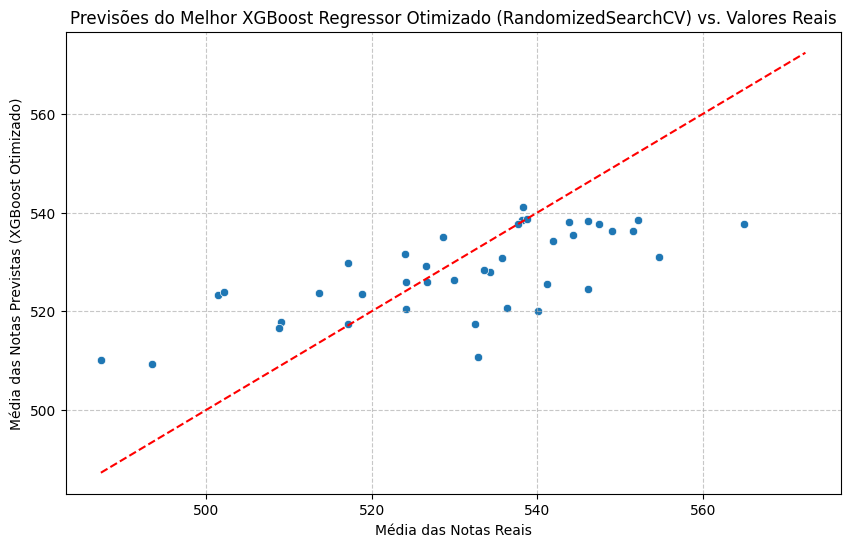

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_best_xgb_random)
plt.xlabel('Média das Notas Reais')
plt.ylabel('Média das Notas Previstas (XGBoost Otimizado)')
plt.title('Previsões do Melhor XGBoost Regressor Otimizado (RandomizedSearchCV) vs. Valores Reais')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Linha de 45 graus para referência
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### GradientBoostingRegressor

##### 3.29 Testando o GradientBoostingRegressor

Agora vamos aplicar o algoritmo GradientBoostingRegressor para ver como ele se comporta em comparação com o Random Forest.

In [136]:
from sklearn.ensemble import GradientBoostingRegressor

# Inicializando e treinando o modelo GradientBoostingRegressor
gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr_model.fit(X_train, y_train)

print("Modelo GradientBoostingRegressor treinado com sucesso!")

Modelo GradientBoostingRegressor treinado com sucesso!


##### 3.30 Avaliação do Modelo GradientBoostingRegressor

Vamos avaliar o desempenho do GradientBoostingRegressor usando as métricas MSE e R².

In [137]:
from sklearn.metrics import mean_squared_error, r2_score

# Fazendo previsões no conjunto de teste com GradientBoostingRegressor
y_pred_gbr = gbr_model.predict(X_test)

# Avaliando o modelo GradientBoostingRegressor
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f"GradientBoostingRegressor - Mean Squared Error (MSE): {mse_gbr:.2f}")
print(f"GradientBoostingRegressor - R-squared (R²): {r2_gbr:.2f}")

print("\nComparação com o melhor modelo Random Forest otimizado:")
print(f"MSE Random Forest Otimizado (GridSearchCV): {mse_best_rf:.2f}")
print(f"R² Random Forest Otimizado (GridSearchCV): {r2_best_rf:.2f}")

GradientBoostingRegressor - Mean Squared Error (MSE): 145.03
GradientBoostingRegressor - R-squared (R²): 0.50

Comparação com o melhor modelo Random Forest otimizado:
MSE Random Forest Otimizado (GridSearchCV): 134.76
R² Random Forest Otimizado (GridSearchCV): 0.54


##### 3.31 Visualização das Previsões do GradientBoostingRegressor vs. Valores Reais

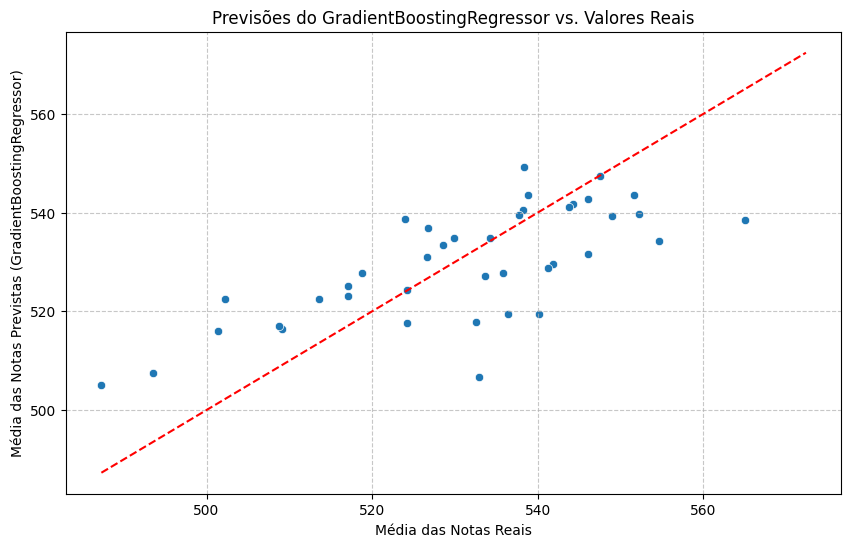

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_gbr)
plt.xlabel('Média das Notas Reais')
plt.ylabel('Média das Notas Previstas (GradientBoostingRegressor)')
plt.title('Previsões do GradientBoostingRegressor vs. Valores Reais')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Linha de 45 graus para referência
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### GradientBoosting otimizado (GridSearchCV)

##### 3.32 Otimização de Hiperparâmetros com GridSearchCV para GradientBoostingRegressor

Vamos usar o `GridSearchCV` para otimizar o GradientBoostingRegressor, buscando a melhor combinação de hiperparâmetros.

In [139]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# Definir o espaço de busca dos hiperparâmetros para GradientBoostingRegressor
param_grid_gbr = {
    'n_estimators': [50, 100, 200],  # Número de estimadores (árvores)
    'learning_rate': [0.01, 0.1, 0.2], # Taxa de aprendizado
    'max_depth': [3, 5, 7],        # Profundidade máxima de cada árvore
    'subsample': [0.7, 0.9, 1.0],    # Fração de amostras para o crescimento das árvores
    'max_features': ['sqrt', 'log2', None, 0.8] # Número de features a considerar em cada split
}

# Inicializar o modelo GradientBoostingRegressor
gbr_base = GradientBoostingRegressor(random_state=42)

# Configurar o GridSearchCV
grid_search_gbr = GridSearchCV(
    estimator=gbr_base,
    param_grid=param_grid_gbr,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Ajustar o GridSearchCV aos dados de treinamento
grid_search_gbr.fit(X_train, y_train)

print("Grid Search para GradientBoostingRegressor concluído!\n")
print(f"Melhores hiperparâmetros para GradientBoostingRegressor: {grid_search_gbr.best_params_}")
print(f"Melhor R-squared na validação cruzada para GradientBoostingRegressor: {grid_search_gbr.best_score_:.2f}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Grid Search para GradientBoostingRegressor concluído!

Melhores hiperparâmetros para GradientBoostingRegressor: {'learning_rate': 0.01, 'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 200, 'subsample': 0.7}
Melhor R-squared na validação cruzada para GradientBoostingRegressor: 0.45


##### 3.33 Avaliação do Melhor Modelo GradientBoostingRegressor Otimizado com GridSearchCV

Agora, vamos avaliar o melhor modelo GradientBoostingRegressor encontrado pelo `GridSearchCV` no conjunto de teste.

In [140]:
from sklearn.metrics import mean_squared_error, r2_score

# Obter o melhor modelo GradientBoostingRegressor
best_gbr_grid_model = grid_search_gbr.best_estimator_

# Fazer previsões no conjunto de teste com o melhor modelo GradientBoostingRegressor
y_pred_best_gbr_grid = best_gbr_grid_model.predict(X_test)

# Avaliar o melhor modelo GradientBoostingRegressor
mse_best_gbr_grid = mean_squared_error(y_test, y_pred_best_gbr_grid)
r2_best_gbr_grid = r2_score(y_test, y_pred_best_gbr_grid)

print(f"Melhor GradientBoostingRegressor (GridSearchCV) - Mean Squared Error (MSE): {mse_best_gbr_grid:.2f}")
print(f"Melhor GradientBoostingRegressor (GridSearchCV) - R-squared (R²): {r2_best_gbr_grid:.2f}")

print("\nComparação com o modelo GradientBoostingRegressor sem otimização:")
print(f"MSE sem otimização: {mse_gbr:.2f}")
print(f"R² sem otimização: {r2_gbr:.2f}")

print("\nO modelo sem otimização se saiu melhor do que o otimizado.")

print("\nComparação com o melhor modelo Random Forest otimizado (GridSearchCV):")
print(f"Random Forest - MSE GridSearchCV: {mse_best_rf:.2f}")
print(f"Random Forest - R² GridSearchCV: {r2_best_rf:.2f}")

Melhor GradientBoostingRegressor (GridSearchCV) - Mean Squared Error (MSE): 150.04
Melhor GradientBoostingRegressor (GridSearchCV) - R-squared (R²): 0.48

Comparação com o modelo GradientBoostingRegressor sem otimização:
MSE sem otimização: 145.03
R² sem otimização: 0.50

O modelo sem otimização se saiu melhor do que o otimizado.

Comparação com o melhor modelo Random Forest otimizado (GridSearchCV):
Random Forest - MSE GridSearchCV: 134.76
Random Forest - R² GridSearchCV: 0.54


##### 3.34 Visualização das Previsões do Melhor GradientBoostingRegressor Otimizado (GridSearchCV) vs. Valores Reais

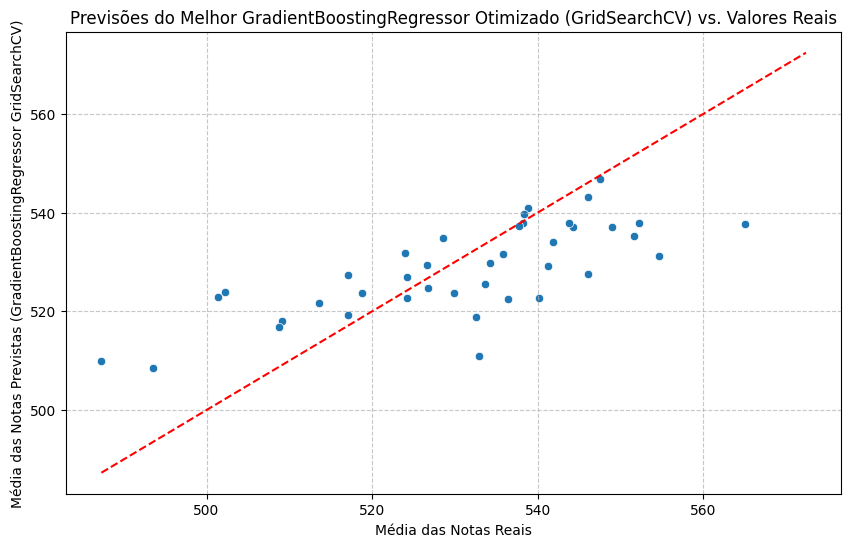

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_best_gbr_grid)
plt.xlabel('Média das Notas Reais')
plt.ylabel('Média das Notas Previstas (GradientBoostingRegressor GridSearchCV)')
plt.title('Previsões do Melhor GradientBoostingRegressor Otimizado (GridSearchCV) vs. Valores Reais')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Linha de 45 graus para referência
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### GradientBoosting otimizado (RandomizedSearchCV)

##### 3.35 Otimização de Hiperparâmetros com RandomizedSearchCV para GradientBoostingRegressor

Vamos usar o `RandomizedSearchCV` para otimizar o GradientBoostingRegressor, buscando a melhor combinação de hiperparâmetros.

In [142]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Definir o espaço de busca dos hiperparâmetros para GradientBoostingRegressor
param_distributions_gbr = {
    'n_estimators': randint(low=50, high=300),
    'learning_rate': uniform(loc=0.01, scale=0.2),
    'max_depth': randint(low=3, high=10),
    'subsample': uniform(loc=0.6, scale=0.4),
    'max_features': uniform(loc=0.6, scale=0.4) # Fração de features para cada estimador
}

# Inicializar o modelo GradientBoostingRegressor
gbr_base = GradientBoostingRegressor(random_state=42)

# Configurar o RandomizedSearchCV
random_search_gbr = RandomizedSearchCV(
    estimator=gbr_base,
    param_distributions=param_distributions_gbr,
    n_iter=50,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Ajustar o RandomizedSearchCV aos dados de treinamento padronizados
random_search_gbr.fit(X_train, y_train)

print("Randomized Search para GradientBoostingRegressor concluído!\n")
print(f"Melhores hiperparâmetros para GradientBoostingRegressor: {random_search_gbr.best_params_}")
print(f"Melhor R-squared na validação cruzada para GradientBoostingRegressor: {random_search_gbr.best_score_:.2f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Randomized Search para GradientBoostingRegressor concluído!

Melhores hiperparâmetros para GradientBoostingRegressor: {'learning_rate': np.float64(0.06696809887549353), 'max_depth': 3, 'max_features': np.float64(0.706712405710114), 'n_estimators': 51, 'subsample': np.float64(0.8010716092915446)}
Melhor R-squared na validação cruzada para GradientBoostingRegressor: 0.44


##### 3.36 Avaliação do Melhor Modelo GradientBoostingRegressor Otimizado com RandomizedSearchCV

Agora, vamos avaliar o melhor modelo GradientBoostingRegressor encontrado pelo `RandomizedSearchCV` no conjunto de teste.

In [143]:
from sklearn.metrics import mean_squared_error, r2_score

# Obter o melhor modelo GradientBoostingRegressor
best_gbr_model = random_search_gbr.best_estimator_

# Fazer previsões no conjunto de teste com o melhor modelo GradientBoostingRegressor
y_pred_best_gbr = best_gbr_model.predict(X_test)

# Avaliar o melhor modelo GradientBoostingRegressor
mse_best_gbr = mean_squared_error(y_test, y_pred_best_gbr)
r2_best_gbr = r2_score(y_test, y_pred_best_gbr)

print(f"Melhor GradientBoostingRegressor (RandomizedSearchCV) - Mean Squared Error (MSE): {mse_best_gbr:.2f}")
print(f"Melhor GradientBoostingRegressor (RandomizedSearchCV) - R-squared (R²): {r2_best_gbr:.2f}")

print("\nComparação com o modelo GradientBoostingRegressor sem otimização:")
print(f"MSE sem otimização: {mse_gbr:.2f}")
print(f"R² sem otimização: {r2_gbr:.2f}")

print("\nComparação com o melhor modelo Random Forest otimizado (GridSearchCV):")
print(f"Random Forest - MSE GridSearchCV: {mse_best_rf:.2f}")
print(f"Random Forest - R² GridSearchCV: {r2_best_rf:.2f}")

print("""
\nO GradientBooster otimizado com o RandomizedSearchCV se saiu melhor do que sem
a otimização. Contudo, sua performance ficou abaixo do melhor modelo Random Forest
otimizado com GridSearchCV.
""")

Melhor GradientBoostingRegressor (RandomizedSearchCV) - Mean Squared Error (MSE): 144.74
Melhor GradientBoostingRegressor (RandomizedSearchCV) - R-squared (R²): 0.50

Comparação com o modelo GradientBoostingRegressor sem otimização:
MSE sem otimização: 145.03
R² sem otimização: 0.50

Comparação com o melhor modelo Random Forest otimizado (GridSearchCV):
Random Forest - MSE GridSearchCV: 134.76
Random Forest - R² GridSearchCV: 0.54


O GradientBooster otimizado com o RandomizedSearchCV se saiu melhor do que sem
a otimização. Contudo, sua performance ficou abaixo do melhor modelo Random Forest
otimizado com GridSearchCV.



##### 3.37 Visualização das Previsões do Melhor GradientBoostingRegressor Otimizado com RandomizedSearchCV vs. Valores Reais

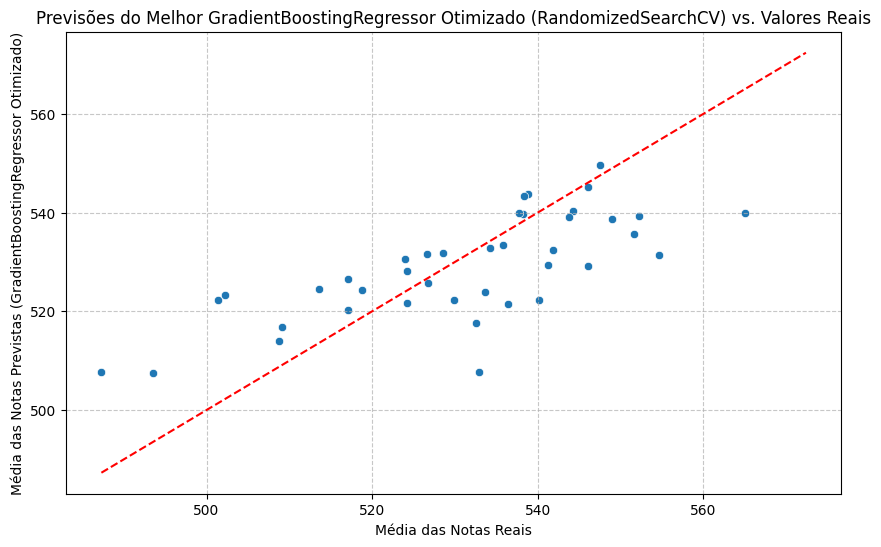

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_best_gbr)
plt.xlabel('Média das Notas Reais')
plt.ylabel('Média das Notas Previstas (GradientBoostingRegressor Otimizado)')
plt.title('Previsões do Melhor GradientBoostingRegressor Otimizado (RandomizedSearchCV) vs. Valores Reais')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Linha de 45 graus para referência
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Conclusões

Dentre todos os algoritmos testados, o que obteve os melhores resultados foi o `Random Forest com os hiperparâmetros otimizados com o GridSearchCV`.

##### Explicação das métricas de avaliação do modelo

In [145]:
print(f"""
- Mean Squared Error (MSE): {mse_best_rf:.2f}
    O MSE mede a média dos quadrados dos erros (diferenças) entre os valores reais (observados) e os valores previstos pelo modelo.
    Em termos simples, ele quantifica o quão longe as previsões do seu modelo estão dos valores verdadeiros.
    Quanto menor o MSE, melhor o modelo, pois indica que os erros de previsão são pequenos.
    O valor de {mse_best_rf:.2f} significa que, em média, o quadrado da diferença entre a nota média real e a nota média prevista pelo modelo é {mse_best_rf:.2f}. 
    A raiz quadrada do MSE (aproximadamente {mse_best_rf**0.5:.2f}) pode ser interpretada como o desvio médio das previsões em relação aos valores reais.
- R-squared (R²): {r2_best_rf:.2f}
    O R-squared, ou coeficiente de determinação, é uma métrica que indica a proporção da variância na variável dependente (neste caso, "media_notas")
    que é explicada pelas variáveis independentes (os indicadores do censo) no modelo. Ele varia de 0 a 1 (ou 0% a 100%).
    Um R² de {r2_best_rf:.2f} (ou {r2_best_rf * 100:.0f}%) significa que aproximadamente {r2_best_rf * 100:.0f}% da variação nas notas médias pode ser explicada pelo modelo,
    utilizando as variáveis ipdm, rendimento_domiciliar_per_capita, taxa_alfabetizacao e taxa_acesso_ensino_superior.
    Os {(1 - r2_best_rf) * 100:.0f}% restantes da variação (1 - {r2_best_rf:.2f} = {(1 - r2_best_rf):.2f}) não são explicados por essas variáveis no modelo
    e podem ser atribuídos a outras variáveis não incluídas no modelo ou a um erro aleatório.
    """)
    
print("""\nAlgumas categorias de variáveis que poderiam ser exploradas para capturar essa variação incluem:
    - Variáveis Individuais do Aluno:
        - Nível Socioeconômico Individual: Embora tenhamos usado rendimento_domiciliar_per_capita a nível municipal, o nível socioeconômico de cada estudante
        (renda familiar, escolaridade dos pais, acesso a bens de consumo) é um preditor muito forte do desempenho.
        Os microdados do ENEM contêm informações mais detalhadas sobre isso, mas não foram vinculadas por questões de LGPD.
        - Raça/Cor: Desigualdades educacionais muitas vezes se manifestam de forma diferente entre grupos raciais.
        - Gênero: Diferenças de desempenho e engajamento podem existir entre gêneros.
        - Idade do Participante: A idade pode influenciar o desempenho, especialmente em testes padronizados como o ENEM.
        - Experiência Educacional Prévia: Participação em cursinhos preparatórios, qualidade do ensino fundamental, repetições de ano.
        - Engajamento e Aspirações: Motivação para os estudos, aspirações profissionais e acadêmicas, tempo dedicado aos estudos.
    - Variáveis da Escola (além da categoria administrativa):
        - Qualidade do Corpo Docente: Formação dos professores, experiência, rotatividade, salários, número de professores por aluno.
        - Infraestrutura da Escola: Acesso a laboratórios, bibliotecas, internet de alta velocidade, espaços esportivos.
        - Metodologias de Ensino: Abordagens pedagógicas inovadoras, foco em disciplinas específicas, programas de reforço.
        - Clima Escolar: Nível de segurança, satisfação de alunos e professores, taxas de abandono.
        - Investimento por Aluno: O montante de recursos financeiros investidos por aluno na escola.
        - Média do ENEM da escola em anos anteriores: Um histórico do desempenho da escola pode ser um forte preditor.
    - Variáveis Contextuais/Políticas Educacionais:
        - Políticas Educacionais Locais: Programas de incentivo à educação, bolsas de estudo, programas de acompanhamento pedagógico implementados pelo município.
        - Investimento Municipal em Educação: Percentual do orçamento municipal destinado à educação.
        - Acesso a Recursos Complementares: Disponibilidade de bibliotecas públicas, centros culturais, oportunidades de estágio na região.
        - Violência Urbana: Níveis de criminalidade no entorno das escolas podem afetar o aprendizado e a frequência.
    - Variáveis do Ambiente Familiar:
        - Estrutura Familiar: Número de pessoas na residência, arranjos familiares.
        - Capital Cultural: Acesso a livros, viagens, atividades culturais e estímulo intelectual dentro de casa.
      """)


- Mean Squared Error (MSE): 134.76
    O MSE mede a média dos quadrados dos erros (diferenças) entre os valores reais (observados) e os valores previstos pelo modelo.
    Em termos simples, ele quantifica o quão longe as previsões do seu modelo estão dos valores verdadeiros.
    Quanto menor o MSE, melhor o modelo, pois indica que os erros de previsão são pequenos.
    O valor de 134.76 significa que, em média, o quadrado da diferença entre a nota média real e a nota média prevista pelo modelo é 134.76. 
    A raiz quadrada do MSE (aproximadamente 11.61) pode ser interpretada como o desvio médio das previsões em relação aos valores reais.
- R-squared (R²): 0.54
    O R-squared, ou coeficiente de determinação, é uma métrica que indica a proporção da variância na variável dependente (neste caso, "media_notas")
    que é explicada pelas variáveis independentes (os indicadores do censo) no modelo. Ele varia de 0 a 1 (ou 0% a 100%).
    Um R² de 0.54 (ou 54%) significa que aproximadamente 

##### Scatterplot - Valores previstos pelo Random Forest vs. Valores Reais

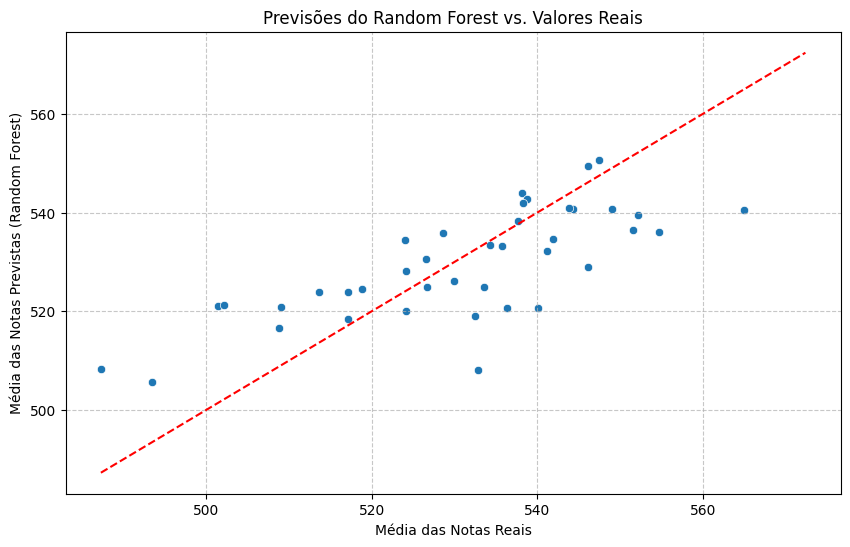


Retomemos, agora, o gráfico com as previsões do Random Forest vs. Valores Reais, para uma breve explicação. Ora, durante a aplicação do algoritmo,
dividu-se o conjunto total de 200 amostras em dois blocos - 160 para o treinamento e 40 para o teste.
O modelo é treinado com o conjunto de treinamento e faz as predições considerando o conjunto de teste - amostras as quais desconhece.
No gráfico acima, a linha de em vermelho mostra o quão aderente foram as previsões do modelo - quanto mais próximos da linha estiverem plotados
os pontos, melhor foi o poder de predição do modelo; havendo sobreposição, predição perfeita.
      


In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_best_rf)
plt.xlabel('Média das Notas Reais')
plt.ylabel('Média das Notas Previstas (Random Forest)')
plt.title('Previsões do Random Forest vs. Valores Reais')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Linha de 45 graus para referência
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"""
Retomemos, agora, o gráfico com as previsões do Random Forest vs. Valores Reais, para uma breve explicação. Ora, durante a aplicação do algoritmo,
dividu-se o conjunto total de {y_train.shape[0] + y_test.shape[0]} amostras em dois blocos - {y_train.shape[0]} para o treinamento e {y_test.shape[0]} para o teste.
O modelo é treinado com o conjunto de treinamento e faz as predições considerando o conjunto de teste - amostras as quais desconhece.
No gráfico acima, a linha de em vermelho mostra o quão aderente foram as previsões do modelo - quanto mais próximos da linha estiverem plotados
os pontos, melhor foi o poder de predição do modelo; havendo sobreposição, predição perfeita.
      """)

##### Análise da Importância das Features do Random Forest

Importância das Features do Random Forest:


,Feature,Importance
1,rendimento_domiciliar_per_capita,0.533776
3,taxa_ensino_superior_completo,0.270398
0,ipdm,0.119267
2,taxa_alfabetizacao,0.076559


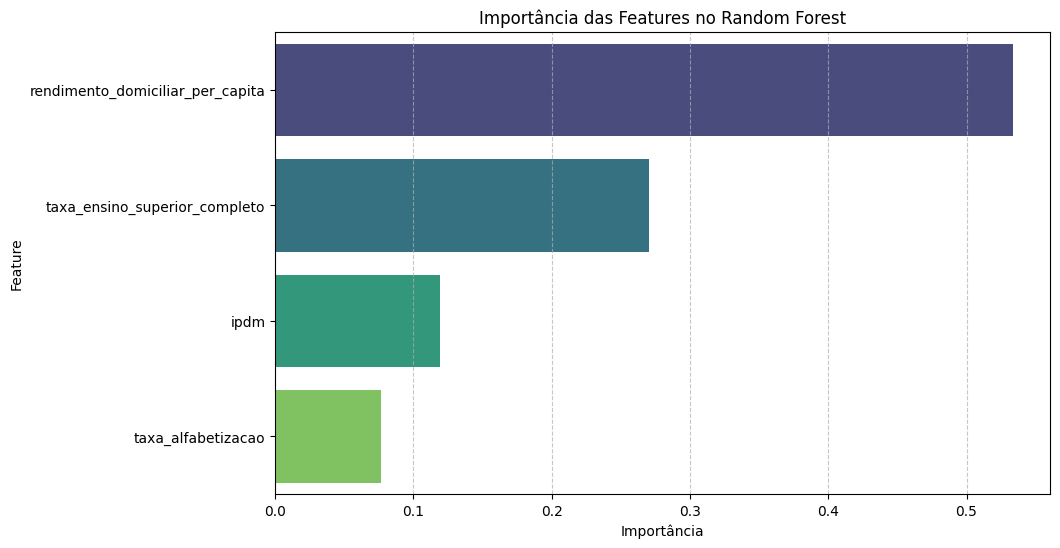


O Random Forest, por ser um modelo baseado em "ensemble", permite discriminar a importância das features. Ela é uma métrica que indica o quanto cada feature
contribui para a precisão e o poder preditivo do modelo. Ela é calculada da seguinte forma:
    Gini Importance (ou Mean Decrease Impurity - MDI):
        - Para cada árvore na floresta, a importância de uma feature é calculada com base na redução da impureza
        (por exemplo, usando o índice Gini para classificação ou erro quadrado médio para regressão) que ela proporciona ao dividir os nós da árvore.
        - Quando um nó é dividido usando uma determinada feature, a redução na impureza é medida. Quanto maior a redução, mais importante é a feature para aquela divisão.
        - A importância total de uma feature em uma única árvore é a soma de todas as reduções de impureza que ela causa em todos os nós onde é usada.
    Média na Floresta (Ensemble Averaging):
        - Como o Random Forest é um ensemble de muitas árvores de 

In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obter a importância das features do modelo Random Forest
feature_importances = best_rf_model.feature_importances_

# Mapear a importância para os nomes das features
features_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})

# Ordenar as features por importância
features_df = features_df.sort_values(by='Importance', ascending=False)

print("Importância das Features do Random Forest:")
display(features_df)

# Visualizar a importância das features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_df, palette='viridis', hue='Feature', legend=False)
plt.title('Importância das Features no Random Forest')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(f"""
O Random Forest, por ser um modelo baseado em "ensemble", permite discriminar a importância das features. Ela é uma métrica que indica o quanto cada feature
contribui para a precisão e o poder preditivo do modelo. Ela é calculada da seguinte forma:
    Gini Importance (ou Mean Decrease Impurity - MDI):
        - Para cada árvore na floresta, a importância de uma feature é calculada com base na redução da impureza
        (por exemplo, usando o índice Gini para classificação ou erro quadrado médio para regressão) que ela proporciona ao dividir os nós da árvore.
        - Quando um nó é dividido usando uma determinada feature, a redução na impureza é medida. Quanto maior a redução, mais importante é a feature para aquela divisão.
        - A importância total de uma feature em uma única árvore é a soma de todas as reduções de impureza que ela causa em todos os nós onde é usada.
    Média na Floresta (Ensemble Averaging):
        - Como o Random Forest é um ensemble de muitas árvores de decisão, a importância final de uma feature é a média das importâncias dessa feature em todas as árvores da floresta.
        - Essa média ajuda a reduzir a variância e fornece uma estimativa mais robusta da importância da feature.
\nA importância das features ajuda a identificar quais features são as mais influentes na tomada de decisões do modelo,
bem com fornece uma maneira de entender melhor o modelo e o problema em questão, mostrando quais variáveis são mais críticas para a previsão.
\nA análise da importância das features no nosso modelo revela o seguinte:
    - Rendimento Domiciliar Per Capita ({features_df['Importance'][1]:.6f}): Esta é a feature mais importante de longe.
        Ela sozinha contribui com mais de {features_df['Importance'][1] * 100:.0f}% da importância total, indicando que o poder aquisitivo da população de um município é o fator mais relevante para prever a média das notas no ENEM.
    - Taxa de Acesso ao Ensino Superior ({features_df['Importance'][3]:.6f}): A taxa de acesso ao ensino superior ocupa a segunda posição, com cerca de {features_df['Importance'][3] * 100:.0f}% de importância.
        Municípios com maior taxa de acesso tendem a ter melhores resultados no ENEM, possivelmente refletindo um ambiente que valoriza mais a educação e oferece mais oportunidades de progressão acadêmica.
    - IPDM ({features_df['Importance'][0]:.6f}): O Índice Paulista de Desenvolvimento Municipal é a terceira feature mais importante, com aproximadamente {features_df['Importance'][0] * 100:.0f}% de importância.
        Isso sugere que o nível geral de desenvolvimento do município (que inclui aspectos econômicos, sociais e ambientais) também tem um impacto considerável na performance dos estudantes.
    - Taxa de Alfabetização ({features_df['Importance'][2]:.6f}): A taxa de alfabetização, embora ainda relevante, é a menos importante das quatro features, com aproximadamente {features_df['Importance'][2] * 100:.0f}%.
        Embora a alfabetização seja fundamental, sua influência direta na média das notas do ENEM pode ser menor quando outras variáveis socioeconômicas e de acesso à educação já estão presentes no modelo.
\nConclusão: O rendimento_domiciliar_per_capita é a feature mais dominante na previsão das notas médias do ENEM neste modelo. Isso reforça a ideia de que fatores socioeconômicos têm um peso significativo no desempenho educacional.
      """)